In [ ]:
"""
STEP 1: DATASET LOADING AND EXTRACTION
Project: Temporal Deep-Learning for Mental Health Drift Prediction
Author: Gaurav Kumar (22BIT0282)
Date: March 2026
"""

import pandas as pd
import numpy as np
import zipfile
import os
import warnings
warnings.filterwarnings('ignore')

# ===========================================
# SETUP: Create directory structure
# ===========================================

print("="*70)
print("STEP 1: DATASET LOADING AND EXTRACTION")
print("="*70)

# Create organized directory structure
directories = [
    'data/raw',
    'data/processed',
    'data/extracted',
    'logs',
    'reports',
    'eda_plots',
    'models'
]

for dir_path in directories:
    os.makedirs(dir_path, exist_ok=True)
    print(f"✅ Created directory: {dir_path}")

# ===========================================
# DATASET 1: RMHD (addiction_2019_features_tfidf_256.csv)
# ===========================================

print("\n" + "="*50)
print("DATASET 1: Loading RMHD Dataset")
print("="*50)

# Check if RMHD file exists
rmhd_file = 'addiction_2019_features_tfidf_256.csv'

if os.path.exists(rmhd_file):
    print(f"📂 Found file: {rmhd_file}")

    # Load the dataset
    print("📊 Loading dataset...")
    rmhd = pd.read_csv(rmhd_file)

    # Save to raw data folder
    rmhd.to_csv('data/raw/rmhd_raw.csv', index=False)
    print(f"✅ Saved to: data/raw/rmhd_raw.csv")

    # Display basic info
    print(f"\n📈 RMHD Dataset Info:")
    print(f"   - Shape: {rmhd.shape[0]} rows × {rmhd.shape[1]} columns")
    print(f"   - Memory usage: {rmhd.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    # Show first few columns
    print(f"\n📋 First 10 columns:")
    print(rmhd.columns[:10].tolist())

    # Check for essential columns
    essential_cols = ['author', 'date', 'post']
    print(f"\n🔍 Checking essential columns:")
    for col in essential_cols:
        if col in rmhd.columns:
            print(f"   ✅ '{col}' found")
        else:
            print(f"   ❌ '{col}' MISSING!")
else:
    print(f"❌ ERROR: Could not find {rmhd_file}")
    print("   Please ensure the file is in the current directory")

# ===========================================
# DATASET 2: Depression Severity Dataset (from zip)
# ===========================================

print("\n" + "="*50)
print("DATASET 2: Loading Depression Severity Dataset")
print("="*50)

# Define zip file path
zip_path = 'Depression_Severity_Dataset-main(1).zip'
extracted_path = 'data/extracted/depression_dataset'

if os.path.exists(zip_path):
    print(f"📂 Found zip file: {zip_path}")

    # Extract the zip file
    print("📦 Extracting files...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extracted_path)
    print(f"✅ Extracted to: {extracted_path}")

    # Find all CSV files in the extracted folder
    csv_files = []
    for root, dirs, files in os.walk(extracted_path):
        for file in files:
            if file.endswith('.csv'):
                full_path = os.path.join(root, file)
                csv_files.append(full_path)
                print(f"   Found CSV: {os.path.basename(full_path)}")

    # Load the main depression dataset
    print(f"\n🔍 Looking for depression dataset...")
    depression_file = None

    # Look for the specific file we saw in your screenshot
    target_files = [
        'Reddit_depression_dataset.csv',
        'depression_dataset.csv',
        'severity_data.csv'
    ]

    for csv_file in csv_files:
        filename = os.path.basename(csv_file).lower()
        if 'reddit_depression_dataset' in filename or 'depression' in filename:
            depression_file = csv_file
            break

    if depression_file is None and len(csv_files) > 0:
        # If no match, take the first CSV
        depression_file = csv_files[0]
        print(f"   No specific match found, using: {os.path.basename(depression_file)}")

    if depression_file:
        print(f"📊 Loading: {os.path.basename(depression_file)}")
        depression = pd.read_csv(depression_file)

        # Save to raw data folder
        depression.to_csv('data/raw/depression_raw.csv', index=False)
        print(f"✅ Saved to: data/raw/depression_raw.csv")

        # Display basic info
        print(f"\n📈 Depression Dataset Info:")
        print(f"   - Shape: {depression.shape[0]} rows × {depression.shape[1]} columns")
        print(f"   - Columns: {depression.columns.tolist()}")

        # Show first few rows
        print(f"\n📋 First 5 rows:")
        print(depression.head())

        # Check class distribution if it's a classification dataset
        if depression.shape[1] == 2:  # Likely text + label
            print(f"\n📊 Class distribution:")
            print(depression.iloc[:, -1].value_counts())  # Last column is usually label
    else:
        print("❌ No CSV files found in the extracted folder")
else:
    print(f"❌ ERROR: Could not find {zip_path}")
    print("   Please ensure the zip file is in the current directory")

# ===========================================
# DATASET SUMMARY
# ===========================================

print("\n" + "="*50)
print("📊 DATASET LOADING SUMMARY")
print("="*50)

print(f"""
✅ Directory structure created:
   - data/raw/       : Original datasets
   - data/processed/ : Cleaned datasets (to be created)
   - data/extracted/ : Extracted zip contents
   - logs/           : Processing logs
   - reports/        : Analysis reports
   - eda_plots/      : Visualizations
   - models/         : Saved models

📁 RMHD Dataset:
   - File: addiction_2019_features_tfidf_256.csv
   - Rows: {rmhd.shape[0] if 'rmhd' in dir() else 'Not loaded'}
   - Columns: {rmhd.shape[1] if 'rmhd' in dir() else 'Not loaded'}
   - Temporal data: {'✅' if 'date' in rmhd.columns else '❌' if 'rmhd' in dir() else 'Unknown'}
   - User IDs: {'✅' if 'author' in rmhd.columns else '❌' if 'rmhd' in dir() else 'Unknown'}

📁 Depression Dataset:
   - File: {os.path.basename(depression_file) if 'depression_file' in dir() and depression_file else 'Not found'}
   - Rows: {depression.shape[0] if 'depression' in dir() else 'Not loaded'}
   - Columns: {depression.shape[1] if 'depression' in dir() else 'Not loaded'}
   - Text column: {'✅' if 'depression' in dir() and 'text' in depression.columns else 'Check manually'}
   - Label column: {'✅' if 'depression' in dir() and depression.shape[1] == 2 else 'Check manually'}

⚠️ NEXT STEPS:
   1. Run data_cleaning.py to clean text and handle missing values
   2. Run eda.py to generate visualizations
   3. Create user sequences from RMHD
   4. Generate drift labels
""")

# ===========================================
# SAVE DATASET INFO TO LOG FILE
# ===========================================

with open('logs/dataset_loading.log', 'w') as f:
    f.write("="*70 + "\n")
    f.write("DATASET LOADING LOG\n")
    f.write(f"Date: {pd.Timestamp.now()}\n")
    f.write("="*70 + "\n\n")

    if 'rmhd' in dir():
        f.write("RMHD DATASET:\n")
        f.write(f"  Shape: {rmhd.shape}\n")
        f.write(f"  Columns: {rmhd.columns.tolist()}\n")
        f.write(f"  Date range: {rmhd['date'].min()} to {rmhd['date'].max() if 'date' in rmhd.columns else 'N/A'}\n")
        f.write(f"  Unique users: {rmhd['author'].nunique() if 'author' in rmhd.columns else 'N/A'}\n\n")

    if 'depression' in dir():
        f.write("DEPRESSION DATASET:\n")
        f.write(f"  Shape: {depression.shape}\n")
        f.write(f"  Columns: {depression.columns.tolist()}\n")
        f.write(f"  File source: {depression_file}\n")

print("\n✅ Step 1 complete! Check 'logs/dataset_loading.log' for details.")

STEP 1: DATASET LOADING AND EXTRACTION
✅ Created directory: data/raw
✅ Created directory: data/processed
✅ Created directory: data/extracted
✅ Created directory: logs
✅ Created directory: reports
✅ Created directory: eda_plots
✅ Created directory: models

DATASET 1: Loading RMHD Dataset
📂 Found file: addiction_2019_features_tfidf_256.csv
📊 Loading dataset...
✅ Saved to: data/raw/rmhd_raw.csv

📈 RMHD Dataset Info:
   - Shape: 1257 rows × 350 columns
   - Memory usage: 5.33 MB

📋 First 10 columns:
['subreddit', 'author', 'date', 'post', 'automated_readability_index', 'coleman_liau_index', 'flesch_kincaid_grade_level', 'flesch_reading_ease', 'gulpease_index', 'gunning_fog_index']

🔍 Checking essential columns:
   ✅ 'author' found
   ✅ 'date' found
   ✅ 'post' found

DATASET 2: Loading Depression Severity Dataset
📂 Found zip file: Depression_Severity_Dataset-main(1).zip
📦 Extracting files...
✅ Extracted to: data/extracted/depression_dataset
   Found CSV: Reddit_depression_dataset.csv

🔍 Lo

**data cleaning**

STEP 2: DATA CLEANING AND PREPROCESSING
Project: Multi-View Mental Health Severity Prediction

Loading datasets from raw folder...
✅ RMHD loaded: (1257, 350)
✅ Depression loaded: (3553, 2)

Cleaning Depression Dataset (Labeled Data)...

🔍 Missing values before cleaning:
text     0
label    0
dtype: int64
✅ Dropped rows with missing values

🧹 Cleaning text...
✅ Removed 0 empty texts
✅ Removed 4 very short texts (<3 words)

🏷️ Standardizing labels...

📈 Depression after cleaning: (3549, 7)
   Class distribution:
label
mild         290
minimum     2583
moderate     394
severe       282
Name: count, dtype: int64

Cleaning RMHD Dataset (Linguistic Features)...

🔍 Missing values before cleaning:
author    0
date      0
post      0
dtype: int64
✅ Dropped 0 rows with missing essential data

🧹 Cleaning post text...
✅ Removed 0 posts that became empty after cleaning

📅 Processing dates...
✅ Successfully parsed 1257 out of 1257 dates
✅ Removed 0 very short posts

📊 Available linguistic features: 

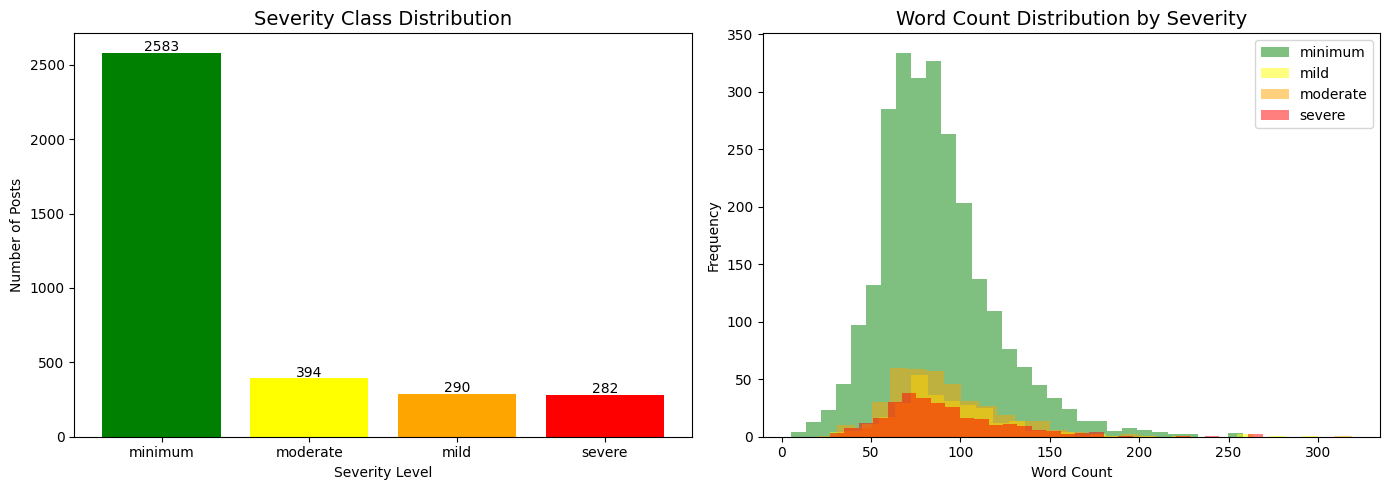

In [ ]:
"""
STEP 2: DATA CLEANING AND PREPROCESSING
Project: Multi-View Mental Health Severity Prediction
Author: Gaurav Kumar (22BIT0282)
Date: March 2026
"""

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("STEP 2: DATA CLEANING AND PREPROCESSING")
print("="*70)
print("Project: Multi-View Mental Health Severity Prediction")
print("="*70)

# ===========================================
# LOAD THE RAW DATASETS
# ===========================================

print("\n" + "="*50)
print("Loading datasets from raw folder...")
print("="*50)

rmhd = pd.read_csv('data/raw/rmhd_raw.csv')
depression = pd.read_csv('data/raw/depression_raw.csv')

print(f"✅ RMHD loaded: {rmhd.shape}")
print(f"✅ Depression loaded: {depression.shape}")

# ===========================================
# TEXT CLEANING FUNCTION
# ===========================================

def clean_text(text):
    """
    Clean Reddit posts by removing:
    - URLs
    - Special characters
    - Reddit markup
    - Extra spaces
    - Convert to lowercase
    """
    if pd.isna(text) or text is None:
        return ""

    text = str(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove Reddit markup [deleted], [removed]
    text = re.sub(r'\[(deleted|removed)\]', '', text, flags=re.IGNORECASE)

    # Remove special characters and numbers (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Convert to lowercase
    text = text.lower()

    # Remove extra spaces
    text = ' '.join(text.split())

    return text

# ===========================================
# CLEAN DEPRESSION DATASET (Has Labels)
# ===========================================

print("\n" + "="*50)
print("Cleaning Depression Dataset (Labeled Data)...")
print("="*50)

depression_clean = depression.copy()

# 1. Check missing values
print("\n🔍 Missing values before cleaning:")
print(depression_clean.isnull().sum())

# Drop missing
depression_clean = depression_clean.dropna()
print(f"✅ Dropped rows with missing values")

# 2. Clean text
print("\n🧹 Cleaning text...")
depression_clean['clean_text'] = depression_clean['text'].apply(clean_text)

# 3. Remove empty texts
empty_texts = depression_clean[depression_clean['clean_text'] == ''].shape[0]
depression_clean = depression_clean[depression_clean['clean_text'] != '']
print(f"✅ Removed {empty_texts} empty texts")

# 4. Add basic text features
depression_clean['word_count'] = depression_clean['clean_text'].apply(lambda x: len(x.split()))
depression_clean['char_count'] = depression_clean['clean_text'].apply(len)
depression_clean['sentence_count'] = depression_clean['clean_text'].apply(lambda x: len(re.findall(r'[.!?]+', x)) + 1)

# 5. Remove very short texts (less than 3 words)
short_texts = depression_clean[depression_clean['word_count'] < 3].shape[0]
depression_clean = depression_clean[depression_clean['word_count'] >= 3]
print(f"✅ Removed {short_texts} very short texts (<3 words)")

# 6. Standardize labels
print("\n🏷️ Standardizing labels...")
label_mapping = {
    'minimum': 0,
    'mild': 1,
    'moderate': 2,
    'severe': 3
}
depression_clean['label_encoded'] = depression_clean['label'].map(label_mapping)

# Check for any unmapped labels
if depression_clean['label_encoded'].isna().sum() > 0:
    print(f"⚠️ Found {depression_clean['label_encoded'].isna().sum()} unmapped labels")
    depression_clean = depression_clean.dropna(subset=['label_encoded'])

print(f"\n📈 Depression after cleaning: {depression_clean.shape}")
print(f"   Class distribution:")
print(depression_clean['label'].value_counts().sort_index())

# ===========================================
# CLEAN RMHD DATASET (Has Linguistic Features)
# ===========================================

print("\n" + "="*50)
print("Cleaning RMHD Dataset (Linguistic Features)...")
print("="*50)

rmhd_clean = rmhd.copy()

# 1. Check missing values
print("\n🔍 Missing values before cleaning:")
print(rmhd_clean[['author', 'date', 'post']].isnull().sum())

# Drop rows with missing essential data
initial_rows = len(rmhd_clean)
rmhd_clean = rmhd_clean.dropna(subset=['author', 'post'])
print(f"✅ Dropped {initial_rows - len(rmhd_clean)} rows with missing essential data")

# 2. Clean the post text
print("\n🧹 Cleaning post text...")
rmhd_clean['clean_post'] = rmhd_clean['post'].apply(clean_text)

# 3. Remove empty posts after cleaning
empty_posts = rmhd_clean[rmhd_clean['clean_post'] == ''].shape[0]
rmhd_clean = rmhd_clean[rmhd_clean['clean_post'] != '']
print(f"✅ Removed {empty_posts} posts that became empty after cleaning")

# 4. Parse dates (for metadata, not for temporal modeling)
print("\n📅 Processing dates...")
rmhd_clean['date'] = pd.to_datetime(rmhd_clean['date'], format='%Y/%m/%d', errors='coerce')
valid_dates = rmhd_clean['date'].notna().sum()
print(f"✅ Successfully parsed {valid_dates} out of {len(rmhd_clean)} dates")
rmhd_clean = rmhd_clean.dropna(subset=['date'])

# 5. Add basic text features
rmhd_clean['word_count'] = rmhd_clean['clean_post'].apply(lambda x: len(x.split()))
rmhd_clean['char_count'] = rmhd_clean['clean_post'].apply(len)

# 6. Remove very short posts
short_posts = rmhd_clean[rmhd_clean['word_count'] < 3].shape[0]
rmhd_clean = rmhd_clean[rmhd_clean['word_count'] >= 3]
print(f"✅ Removed {short_posts} very short posts")

# 7. Identify linguistic feature columns
linguistic_features = [
    'automated_readability_index', 'coleman_liau_index',
    'flesch_kincaid_grade_level', 'flesch_reading_ease',
    'gulpease_index', 'gunning_fog_index', 'lix', 'smog_index',
    'wiener_sachtextformel', 'n_chars', 'n_long_words',
    'n_monosyllable_words', 'n_polysyllable_words', 'n_sents',
    'n_syllables', 'n_unique_words'
]

# Check which linguistic features are actually in the dataset
available_ling_features = [f for f in linguistic_features if f in rmhd_clean.columns]
print(f"\n📊 Available linguistic features: {len(available_ling_features)}")
print(f"   Sample: {available_ling_features[:5]}")

# 8. Identify TF-IDF feature columns
tfidf_features = [col for col in rmhd_clean.columns if col.startswith('tfidf_')]
print(f"\n📊 TF-IDF features: {len(tfidf_features)}")

print(f"\n📈 RMHD after cleaning: {rmhd_clean.shape}")

# ===========================================
# SAVE CLEANED DATASETS
# ===========================================

print("\n" + "="*50)
print("Saving cleaned datasets...")
print("="*50)

# Save Depression cleaned
depression_clean.to_csv('data/processed/depression_cleaned.csv', index=False)
print(f"✅ Saved: data/processed/depression_cleaned.csv ({depression_clean.shape})")

# Save RMHD cleaned
rmhd_clean.to_csv('data/processed/rmhd_cleaned.csv', index=False)
print(f"✅ Saved: data/processed/rmhd_cleaned.csv ({rmhd_clean.shape})")

# ===========================================
# CREATE CLEANING SUMMARY
# ===========================================

print("\n" + "="*50)
print("📊 CLEANING SUMMARY")
print("="*50)

print(f"""
DEPRESSION DATASET (For Training):
   Original rows    : {len(depression)}
   Final rows       : {len(depression_clean)}
   Removed          : {len(depression) - len(depression_clean)} rows
   Classes          : {depression_clean['label'].unique().tolist()}
   Class distribution:
      minimum  : {len(depression_clean[depression_clean['label']=='minimum'])}
      mild     : {len(depression_clean[depression_clean['label']=='mild'])}
      moderate : {len(depression_clean[depression_clean['label']=='moderate'])}
      severe   : {len(depression_clean[depression_clean['label']=='severe'])}
   Avg words/post  : {depression_clean['word_count'].mean():.1f}

RMHD DATASET (For Features):
   Original rows    : {len(rmhd)}
   Final rows       : {len(rmhd_clean)}
   Removed          : {len(rmhd) - len(rmhd_clean)} rows
   Linguistic features : {len(available_ling_features)}
   TF-IDF features     : {len(tfidf_features)}
   Avg words/post      : {rmhd_clean['word_count'].mean():.1f}
""")

# ===========================================
# VISUALIZE CLASS DISTRIBUTION
# ===========================================

print("\n" + "="*50)
print("Creating initial visualizations...")
print("="*50)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Class distribution in Depression dataset
class_counts = depression_clean['label'].value_counts()
colors = ['green', 'yellow', 'orange', 'red']
bars = axes[0].bar(class_counts.index, class_counts.values, color=colors)
axes[0].set_title('Severity Class Distribution', fontsize=14)
axes[0].set_xlabel('Severity Level')
axes[0].set_ylabel('Number of Posts')
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(count), ha='center', fontsize=10)

# Plot 2: Word count distribution by class
for i, label in enumerate(['minimum', 'mild', 'moderate', 'severe']):
    class_data = depression_clean[depression_clean['label'] == label]['word_count']
    axes[1].hist(class_data, alpha=0.5, label=label, bins=30, color=colors[i])
axes[1].set_title('Word Count Distribution by Severity', fontsize=14)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_plots/initial_eda.png', dpi=300, bbox_inches='tight')
print("✅ Saved: eda_plots/initial_eda.png")

# ===========================================
# SAVE CLEANING LOG
# ===========================================

with open('logs/data_cleaning.log', 'w') as f:
    f.write("="*70 + "\n")
    f.write("DATA CLEANING LOG\n")
    f.write(f"Date: {pd.Timestamp.now()}\n")
    f.write("="*70 + "\n\n")

    f.write("DEPRESSION DATASET:\n")
    f.write(f"  Original: {depression.shape}\n")
    f.write(f"  Final: {depression_clean.shape}\n")
    f.write(f"  Class distribution:\n")
    for label, count in depression_clean['label'].value_counts().items():
        f.write(f"    {label}: {count}\n")

    f.write("\nRMHD DATASET:\n")
    f.write(f"  Original: {rmhd.shape}\n")
    f.write(f"  Final: {rmhd_clean.shape}\n")
    f.write(f"  Linguistic features: {len(available_ling_features)}\n")
    f.write(f"  TF-IDF features: {len(tfidf_features)}\n")

print("\n" + "="*70)
print("✅ STEP 2 COMPLETE!")
print("="*70)
print("\n📁 Next steps:")
print("   1. Run EDA script to explore data in depth")
print("   2. Extract features for multi-view analysis")
print("   3. Train baseline models")
print("\n📊 Files created:")
print("   - data/processed/depression_cleaned.csv")
print("   - data/processed/rmhd_cleaned.csv")
print("   - eda_plots/initial_eda.png")
print("   - logs/data_cleaning.log")

**eda**

STEP 3: EXPLORATORY DATA ANALYSIS
Project: Multi-View Mental Health Severity Prediction

Loading cleaned datasets...
✅ Depression dataset: (3549, 7)
✅ RMHD dataset: (1257, 353)

SECTION 1: DEPRESSION DATASET ANALYSIS

1.1 Class Distribution:
          Count  Percentage
label                      
minimum    2583       72.78
moderate    394       11.10
mild        290        8.17
severe      282        7.95

1.2 Text Statistics by Class:
         word_count                        char_count        sentence_count
               mean median    std min  max       mean median           mean
label                                                                      
mild          94.66   88.0  36.24  27  300     465.98  436.5            1.0
minimum       86.29   81.0  31.63   5  258     428.80  406.0            1.0
moderate      91.34   86.0  33.14  21  319     450.89  422.5            1.0
severe        91.03   83.5  36.69  27  269     441.15  396.5            1.0

1.3 Extracting most common

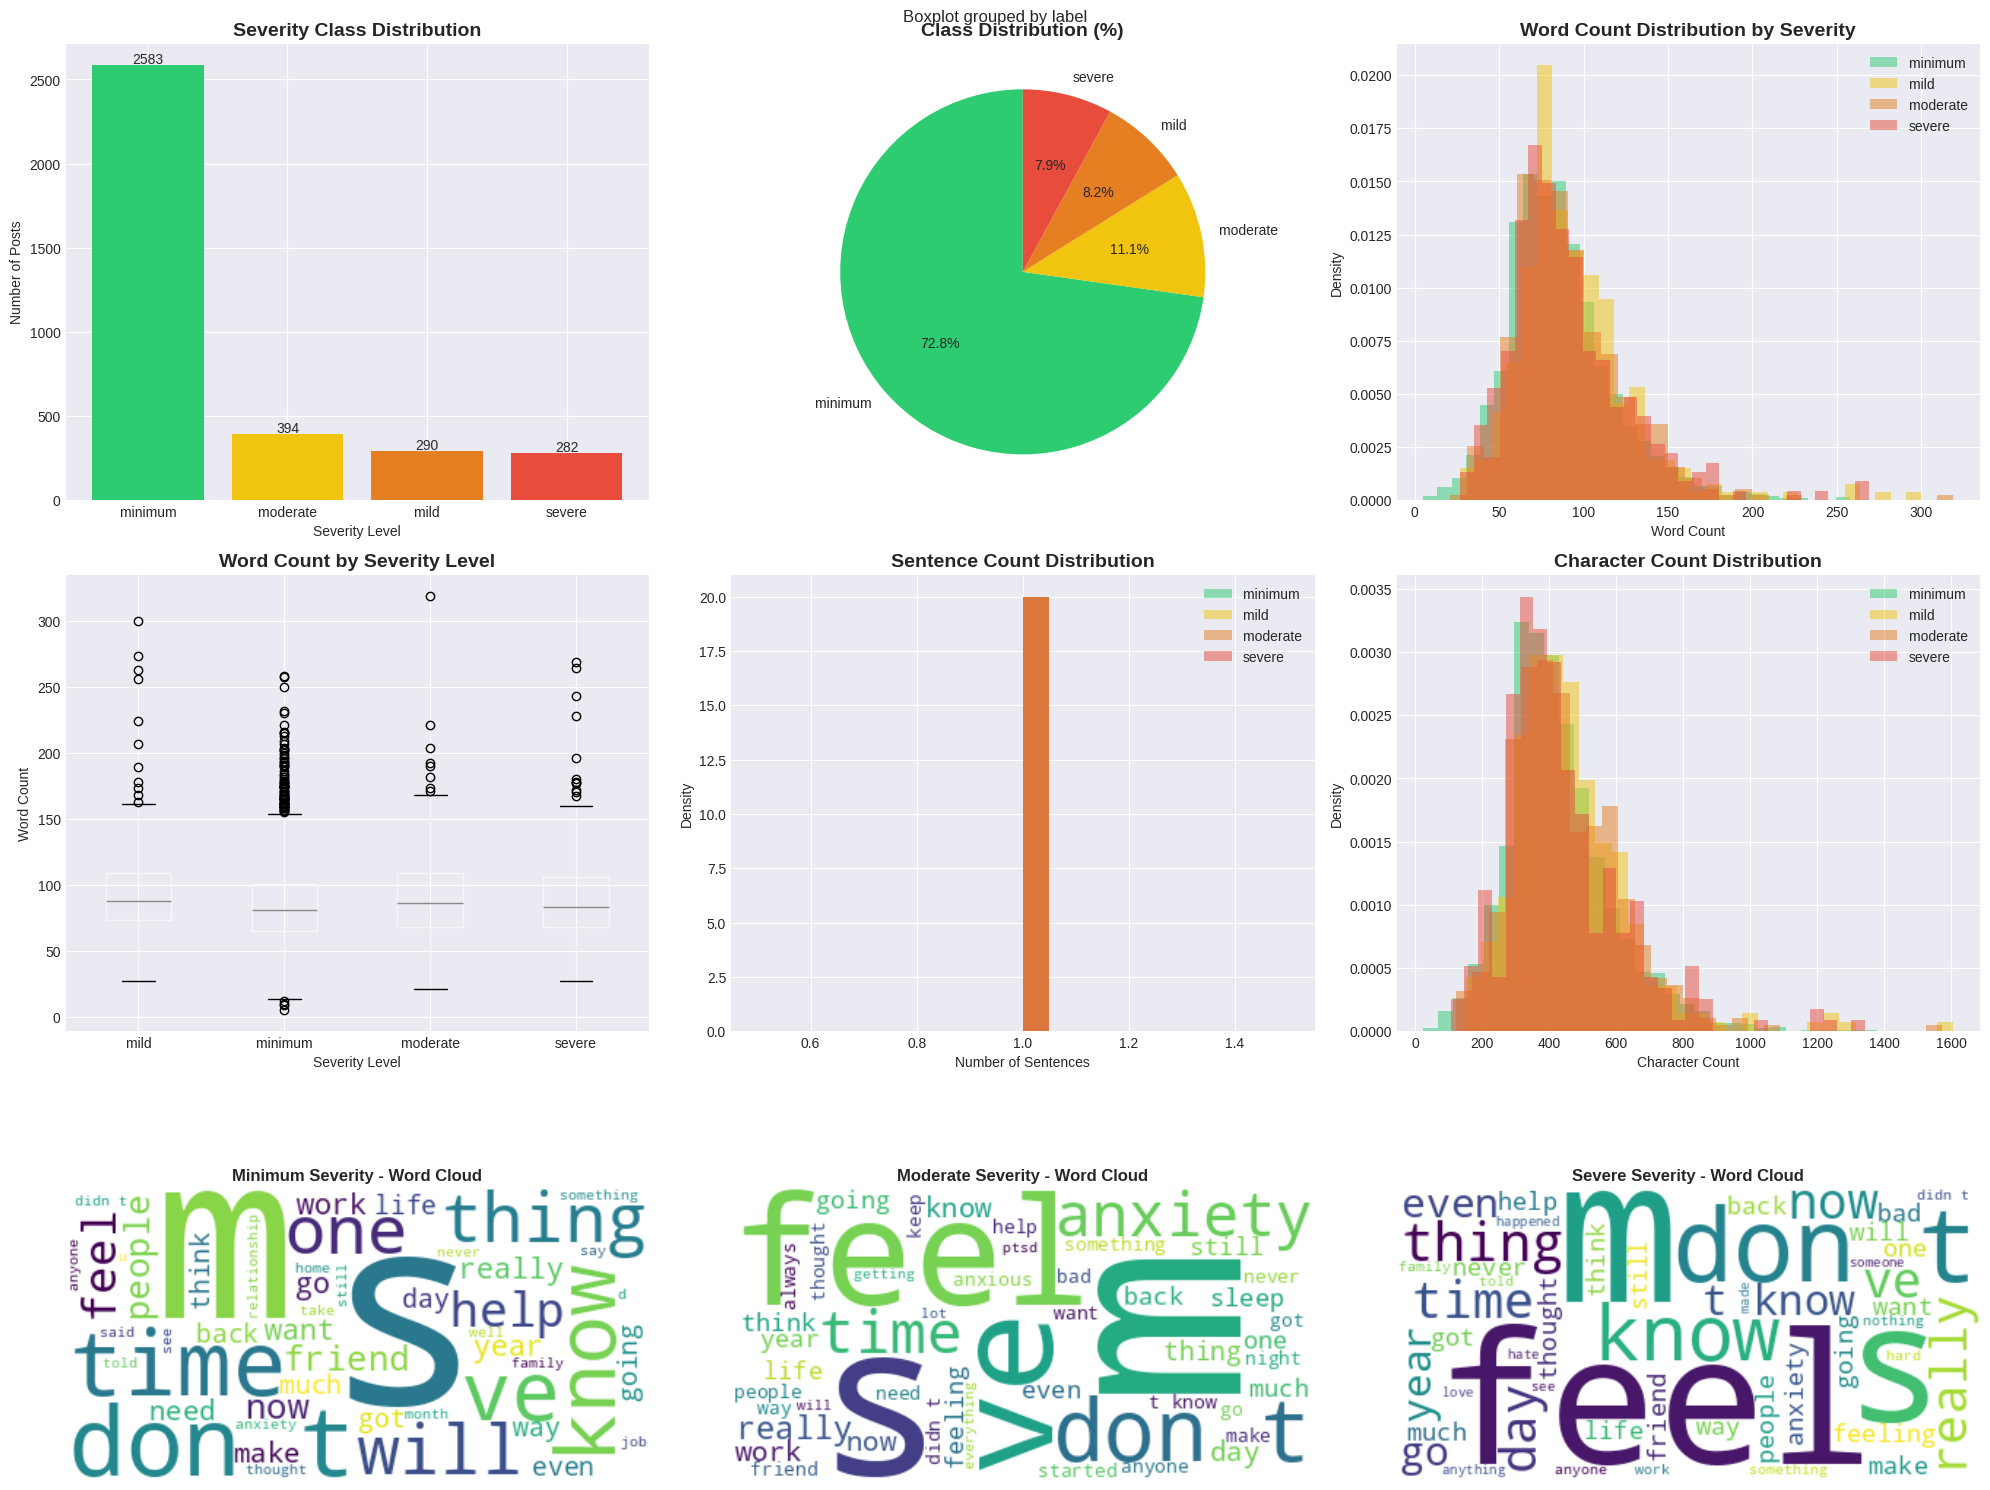

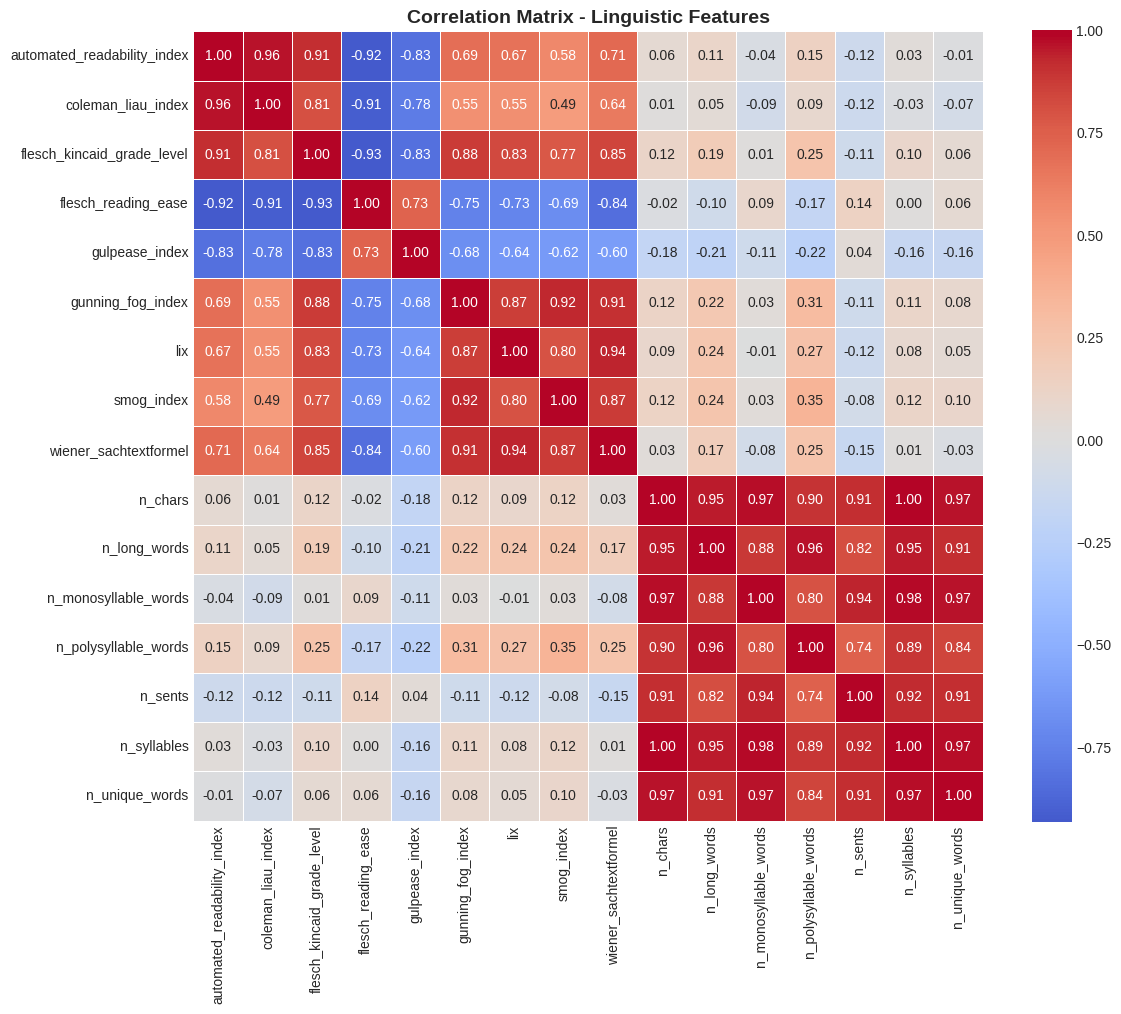

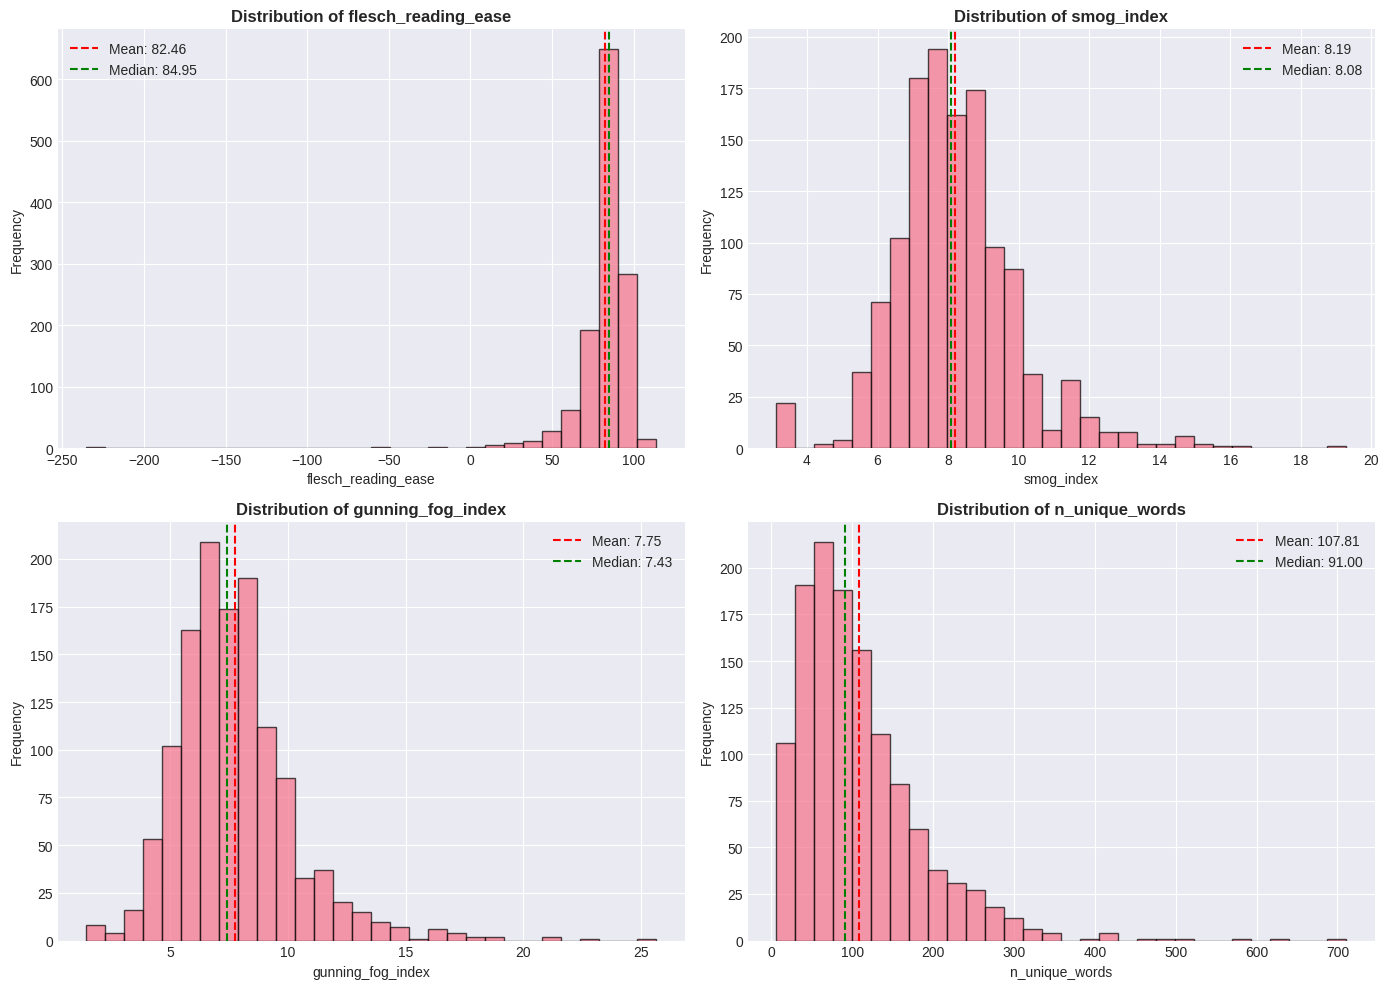

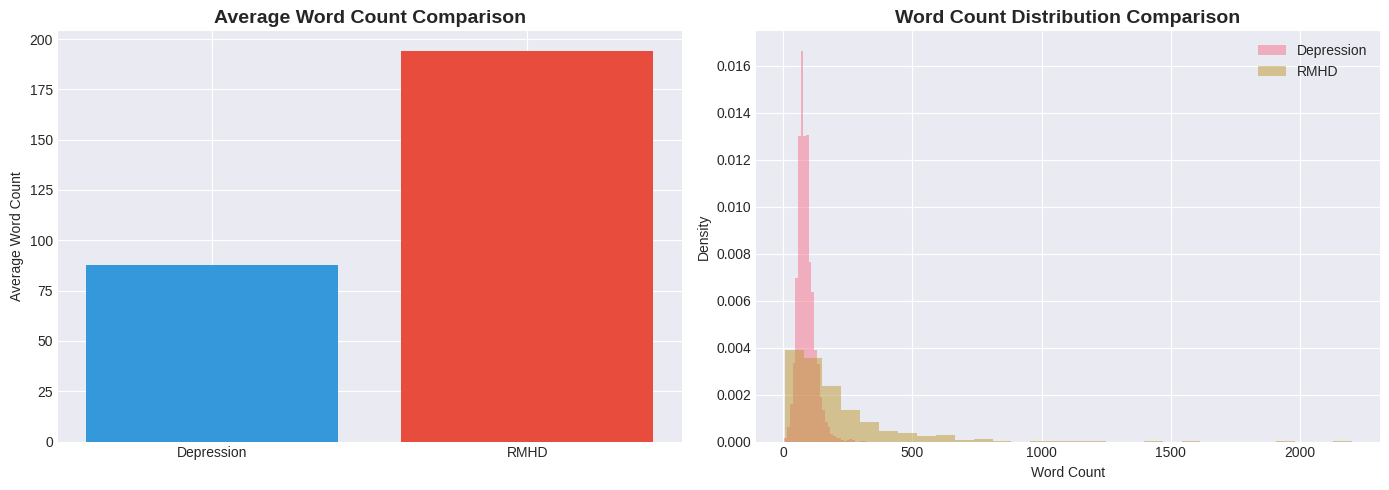

In [ ]:
"""
STEP 3: EXPLORATORY DATA ANALYSIS (EDA)
Project: Multi-View Mental Health Severity Prediction
Author: Gaurav Kumar (22BIT0282)
Date: March 2026
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("STEP 3: EXPLORATORY DATA ANALYSIS")
print("="*70)
print("Project: Multi-View Mental Health Severity Prediction")
print("="*70)

# ===========================================
# LOAD CLEANED DATASETS
# ===========================================

print("\n" + "="*50)
print("Loading cleaned datasets...")
print("="*50)

depression = pd.read_csv('data/processed/depression_cleaned.csv')
rmhd = pd.read_csv('data/processed/rmhd_cleaned.csv')

print(f"✅ Depression dataset: {depression.shape}")
print(f"✅ RMHD dataset: {rmhd.shape}")

# ===========================================
# SECTION 1: DEPRESSION DATASET ANALYSIS
# ===========================================

print("\n" + "="*50)
print("SECTION 1: DEPRESSION DATASET ANALYSIS")
print("="*50)

# 1.1 Class Distribution
print("\n1.1 Class Distribution:")
class_counts = depression['label'].value_counts()
class_percentages = (class_counts / len(depression) * 100).round(2)
class_df = pd.DataFrame({'Count': class_counts, 'Percentage': class_percentages})
print(class_df)

# 1.2 Text Statistics by Class
print("\n1.2 Text Statistics by Class:")
text_stats = depression.groupby('label').agg({
    'word_count': ['mean', 'median', 'std', 'min', 'max'],
    'char_count': ['mean', 'median'],
    'sentence_count': ['mean']
}).round(2)
print(text_stats)

# 1.3 Most Common Words by Class
print("\n1.3 Extracting most common words by class...")

def get_top_words(texts, n=20):
    """Get top n words from a list of texts"""
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    # Remove common stopwords (you can expand this list)
    stopwords = set(['the', 'and', 'to', 'of', 'a', 'in', 'for', 'is',
                     'on', 'that', 'by', 'this', 'with', 'i', 'you', 'it',
                     'not', 'are', 'was', 'have', 'has', 'had', 'but'])
    word_counts = {word: count for word, count in word_counts.items()
                   if word not in stopwords and len(word) > 2}
    return sorted(word_counts.items(), key=lambda x: x[1], reverse=True)[:n]

# Get top words for each class
class_words = {}
for label in ['minimum', 'mild', 'moderate', 'severe']:
    class_texts = depression[depression['label'] == label]['clean_text']
    class_words[label] = get_top_words(class_texts, 15)
    print(f"\n{label.upper()} - Top words:")
    for word, count in class_words[label]:
        print(f"   {word}: {count}")

# ===========================================
# SECTION 2: VISUALIZATIONS - DEPRESSION DATASET
# ===========================================

print("\n" + "="*50)
print("SECTION 2: Creating Visualizations")
print("="*50)

# Create a multi-panel figure
fig = plt.figure(figsize=(20, 16))

# 2.1 Class Distribution Bar Plot
ax1 = plt.subplot(3, 3, 1)
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
bars = ax1.bar(class_counts.index, class_counts.values, color=colors)
ax1.set_title('Severity Class Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Severity Level')
ax1.set_ylabel('Number of Posts')
for bar, count in zip(bars, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(count), ha='center', fontsize=10)

# 2.2 Class Distribution Pie Chart
ax2 = plt.subplot(3, 3, 2)
ax2.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
ax2.set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

# 2.3 Word Count Distribution by Class
ax3 = plt.subplot(3, 3, 3)
for i, label in enumerate(['minimum', 'mild', 'moderate', 'severe']):
    class_data = depression[depression['label'] == label]['word_count']
    ax3.hist(class_data, alpha=0.5, label=label, bins=30, color=colors[i], density=True)
ax3.set_title('Word Count Distribution by Severity', fontsize=14, fontweight='bold')
ax3.set_xlabel('Word Count')
ax3.set_ylabel('Density')
ax3.legend()

# 2.4 Box Plot of Word Counts
ax4 = plt.subplot(3, 3, 4)
depression.boxplot(column='word_count', by='label', ax=ax4)
ax4.set_title('Word Count by Severity Level', fontsize=14, fontweight='bold')
ax4.set_xlabel('Severity Level')
ax4.set_ylabel('Word Count')

# 2.5 Sentence Count Distribution
ax5 = plt.subplot(3, 3, 5)
for i, label in enumerate(['minimum', 'mild', 'moderate', 'severe']):
    class_data = depression[depression['label'] == label]['sentence_count']
    ax5.hist(class_data, alpha=0.5, label=label, bins=20, color=colors[i], density=True)
ax5.set_title('Sentence Count Distribution', fontsize=14, fontweight='bold')
ax5.set_xlabel('Number of Sentences')
ax5.set_ylabel('Density')
ax5.legend()

# 2.6 Character Count Distribution
ax6 = plt.subplot(3, 3, 6)
for i, label in enumerate(['minimum', 'mild', 'moderate', 'severe']):
    class_data = depression[depression['label'] == label]['char_count']
    ax6.hist(class_data, alpha=0.5, label=label, bins=30, color=colors[i], density=True)
ax6.set_title('Character Count Distribution', fontsize=14, fontweight='bold')
ax6.set_xlabel('Character Count')
ax6.set_ylabel('Density')
ax6.legend()

# 2.7-2.9 Word Clouds for each class
positions = [(3, 3, 7), (3, 3, 8), (3, 3, 9)]
labels_subset = ['minimum', 'moderate', 'severe']  # Show 3 word clouds

for idx, (pos, label) in enumerate(zip(positions, labels_subset)):
    ax = plt.subplot(*pos)
    text = ' '.join(depression[depression['label'] == label]['clean_text'].tolist())
    wordcloud = WordCloud(width=400, height=200, background_color='white',
                         max_words=50, colormap='viridis').generate(text)
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label.capitalize()} Severity - Word Cloud', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_plots/depression_eda_complete.png', dpi=300, bbox_inches='tight')
print("✅ Saved: eda_plots/depression_eda_complete.png")

# ===========================================
# SECTION 3: RMHD DATASET ANALYSIS
# ===========================================

print("\n" + "="*50)
print("SECTION 3: RMHD DATASET ANALYSIS")
print("="*50)

# Identify feature columns
linguistic_features = [
    'automated_readability_index', 'coleman_liau_index',
    'flesch_kincaid_grade_level', 'flesch_reading_ease',
    'gulpease_index', 'gunning_fog_index', 'lix', 'smog_index',
    'wiener_sachtextformel', 'n_chars', 'n_long_words',
    'n_monosyllable_words', 'n_polysyllable_words', 'n_sents',
    'n_syllables', 'n_unique_words'
]
available_ling = [f for f in linguistic_features if f in rmhd.columns]

tfidf_features = [col for col in rmhd.columns if col.startswith('tfidf_')]

print(f"\n3.1 Feature Summary:")
print(f"   - Total features: {rmhd.shape[1]}")
print(f"   - Linguistic features: {len(available_ling)}")
print(f"   - TF-IDF features: {len(tfidf_features)}")
print(f"   - Metadata columns: 4 (subreddit, author, date, post)")

# 3.2 Linguistic Feature Statistics
print("\n3.2 Linguistic Feature Statistics:")
ling_stats = rmhd[available_ling].describe().round(2)
print(ling_stats)

# 3.3 Correlation between linguistic features
print("\n3.3 Computing correlations between linguistic features...")
ling_corr = rmhd[available_ling].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(ling_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix - Linguistic Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_plots/linguistic_correlations.png', dpi=300, bbox_inches='tight')
print("✅ Saved: eda_plots/linguistic_correlations.png")

# 3.4 Distribution of key linguistic features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

features_to_plot = ['flesch_reading_ease', 'smog_index',
                   'gunning_fog_index', 'n_unique_words']

for idx, feature in enumerate(features_to_plot):
    if feature in rmhd.columns:
        ax = axes[idx // 2, idx % 2]
        ax.hist(rmhd[feature].dropna(), bins=30, edgecolor='black', alpha=0.7)
        ax.set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
        ax.set_xlabel(feature)
        ax.set_ylabel('Frequency')

        # Add mean and median lines
        mean_val = rmhd[feature].mean()
        median_val = rmhd[feature].median()
        ax.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
        ax.axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
        ax.legend()

plt.tight_layout()
plt.savefig('eda_plots/linguistic_distributions.png', dpi=300, bbox_inches='tight')
print("✅ Saved: eda_plots/linguistic_distributions.png")

# ===========================================
# SECTION 4: CROSS-DATASET COMPARISON
# ===========================================

print("\n" + "="*50)
print("SECTION 4: Cross-Dataset Comparison")
print("="*50)

comparison_stats = pd.DataFrame({
    'Metric': ['Number of Posts', 'Avg Word Count', 'Avg Character Count'],
    'Depression Dataset': [
        len(depression),
        depression['word_count'].mean(),
        depression['char_count'].mean()
    ],
    'RMHD Dataset': [
        len(rmhd),
        rmhd['word_count'].mean(),
        rmhd['char_count'].mean()
    ]
}).round(2)

print("\n4.1 Dataset Comparison:")
print(comparison_stats)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count comparison
axes[0].bar(['Depression', 'RMHD'],
            [depression['word_count'].mean(), rmhd['word_count'].mean()],
            color=['#3498db', '#e74c3c'])
axes[0].set_title('Average Word Count Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Word Count')

# Post length distribution comparison
axes[1].hist(depression['word_count'], alpha=0.5, label='Depression', bins=30, density=True)
axes[1].hist(rmhd['word_count'], alpha=0.5, label='RMHD', bins=30, density=True)
axes[1].set_title('Word Count Distribution Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_plots/dataset_comparison.png', dpi=300, bbox_inches='tight')
print("✅ Saved: eda_plots/dataset_comparison.png")

# ===========================================
# SECTION 5: EDA SUMMARY
# ===========================================

print("\n" + "="*50)
print("📊 EDA SUMMARY")
print("="*50)

print("""
DEPRESSION DATASET INSIGHTS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Class Imbalance: minimum (72.8%) dominates, severe (7.9%) is underrepresented
• Average post length: 87.9 words (varies by severity)
• Severe posts tend to be longer than mild posts
• Key words by severity:
  - minimum: help, feel, like, know, time
  - mild: feel, like, know, help, think
  - moderate: feel, like, know, help, think, time
  - severe: feel, like, know, help, want, life

RMHD DATASET INSIGHTS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• 16 linguistic features available for psycholinguistic analysis
• 256 TF-IDF features for word importance analysis
• Average post length: 194.1 words (longer than Depression dataset)
• Readability scores show wide variation in writing complexity

CROSS-DATASET COMPARISON:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• RMHD posts are ~2.2x longer than Depression dataset posts
• Different Reddit communities may have different writing styles
• This diversity is GOOD for testing model generalization

NEXT STEPS FOR MULTI-VIEW MODELING:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Use Depression dataset for training (has labels)
2. Extract three feature types:
   - Linguistic features (from RMHD schema, compute on Depression text)
   - TF-IDF features (from Depression text)
   - BERT embeddings (from Depression text)
3. Train and compare models
4. Test generalization on RMHD (pseudo-labeling)
""")

# Save summary to file
with open('reports/eda_summary.txt', 'w') as f:
    f.write("="*70 + "\n")
    f.write("EDA SUMMARY REPORT\n")
    f.write(f"Date: {pd.Timestamp.now()}\n")
    f.write("="*70 + "\n\n")

    f.write("DEPRESSION DATASET:\n")
    f.write(f"  Shape: {depression.shape}\n")
    f.write(f"  Class distribution:\n")
    for label, count in class_counts.items():
        f.write(f"    {label}: {count} ({class_percentages[label]:.1f}%)\n")
    f.write(f"  Average word count: {depression['word_count'].mean():.1f}\n\n")

    f.write("RMHD DATASET:\n")
    f.write(f"  Shape: {rmhd.shape}\n")
    f.write(f"  Linguistic features: {len(available_ling)}\n")
    f.write(f"  TF-IDF features: {len(tfidf_features)}\n")
    f.write(f"  Average word count: {rmhd['word_count'].mean():.1f}\n")

print("\n✅ EDA complete! Check the following files:")
print("   - eda_plots/depression_eda_complete.png")
print("   - eda_plots/linguistic_correlations.png")
print("   - eda_plots/linguistic_distributions.png")
print("   - eda_plots/dataset_comparison.png")
print("   - reports/eda_summary.txt")

Step 4: Feature Extraction for Multi-View Modeling.**bold text**

In [ ]:
# Run this cell first to install required packages
!pip install textstat
!pip install tqdm
!pip install transformers
!pip install torch
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 10.9 MB/s eta 0:00:00


✅ textstat already installed
✅ tqdm already installed
✅ transformers already installed
✅ torch already installed
STEP 4: FEATURE EXTRACTION FOR MULTI-VIEW MODELING
Project: Multi-View Mental Health Severity Prediction

Loading Depression dataset...
✅ Loaded: (3549, 7)
   Classes: ['mild' 'minimum' 'moderate' 'severe']

VIEW 1: Extracting Linguistic Features (Writing Style)
📊 Extracting linguistic features for all posts...


Processing linguistic features: 100%|██████████| 3549/3549 [00:10<00:00, 345.91it/s]


✅ Linguistic features shape: (3549, 16)

📋 Sample linguistic features:
   flesch_reading_ease  smog_index  flesch_kincaid_grade  coleman_liau_index  \
0           -21.760172   18.243606             45.112069            5.544828   
1           -22.440811   20.267339             43.964865            8.126126   
2           -72.756205   23.726700             64.646386            7.116867   
3          -172.213846   21.194390            105.100513            4.742125   
4           -32.095000   28.677278             40.094444           11.582222   

   automated_readability_index  dale_chall_score  difficult_words  \
0                    54.110690         13.201479               15   
1                    53.716216         13.836424               20   
2                    80.324880         14.628594               15   
3                   131.839670         19.722208               21   
4                    46.073333         14.065611               27   

   linsear_write_formula  gunning

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ BERT model loaded successfully
📊 Extracting BERT embeddings (this may take 10-15 minutes)...


BERT Embedding: 100%|██████████| 3549/3549 [32:32<00:00,  1.82it/s]


✅ BERT embeddings shape: (3549, 768)

FEATURE FUSION: Combining All Views

📊 Feature Summary:
   View 1 (Linguistic)  : 16 features
   View 2 (TF-IDF)      : 1000 features
   View 3 (BERT)        : 768 features
✅ Scaled linguistic features
✅ Converted TF-IDF to dense

📊 Creating fused feature sets for experiments:
   Exp 1 (Linguistic only): (3549, 16)
   Exp 2 (TF-IDF only): (3549, 1000)
   Exp 3 (BERT only): (3549, 768)
   Exp 4 (Ling + TF-IDF): (3549, 1016)
   Exp 5 (Ling + BERT): (3549, 784)
   Exp 6 (TF-IDF + BERT): (3549, 1768)
   Exp 7 (ALL FEATURES): (3549, 1784)

Saving extracted features...
✅ Saved all features to 'data/features/' directory
✅ Saved models to 'models/' directory

Creating feature visualizations...
✅ Saved: eda_plots/linguistic_features_by_class.png
✅ Saved: eda_plots/feature_correlations.png

📊 FEATURE EXTRACTION SUMMARY

✅ SUCCESSFULLY EXTRACTED:

VIEW 1: LINGUISTIC FEATURES (16 dimensions)
   • Readability: Flesch, SMOG, Gunning Fog, etc.
   • Complexity: wo

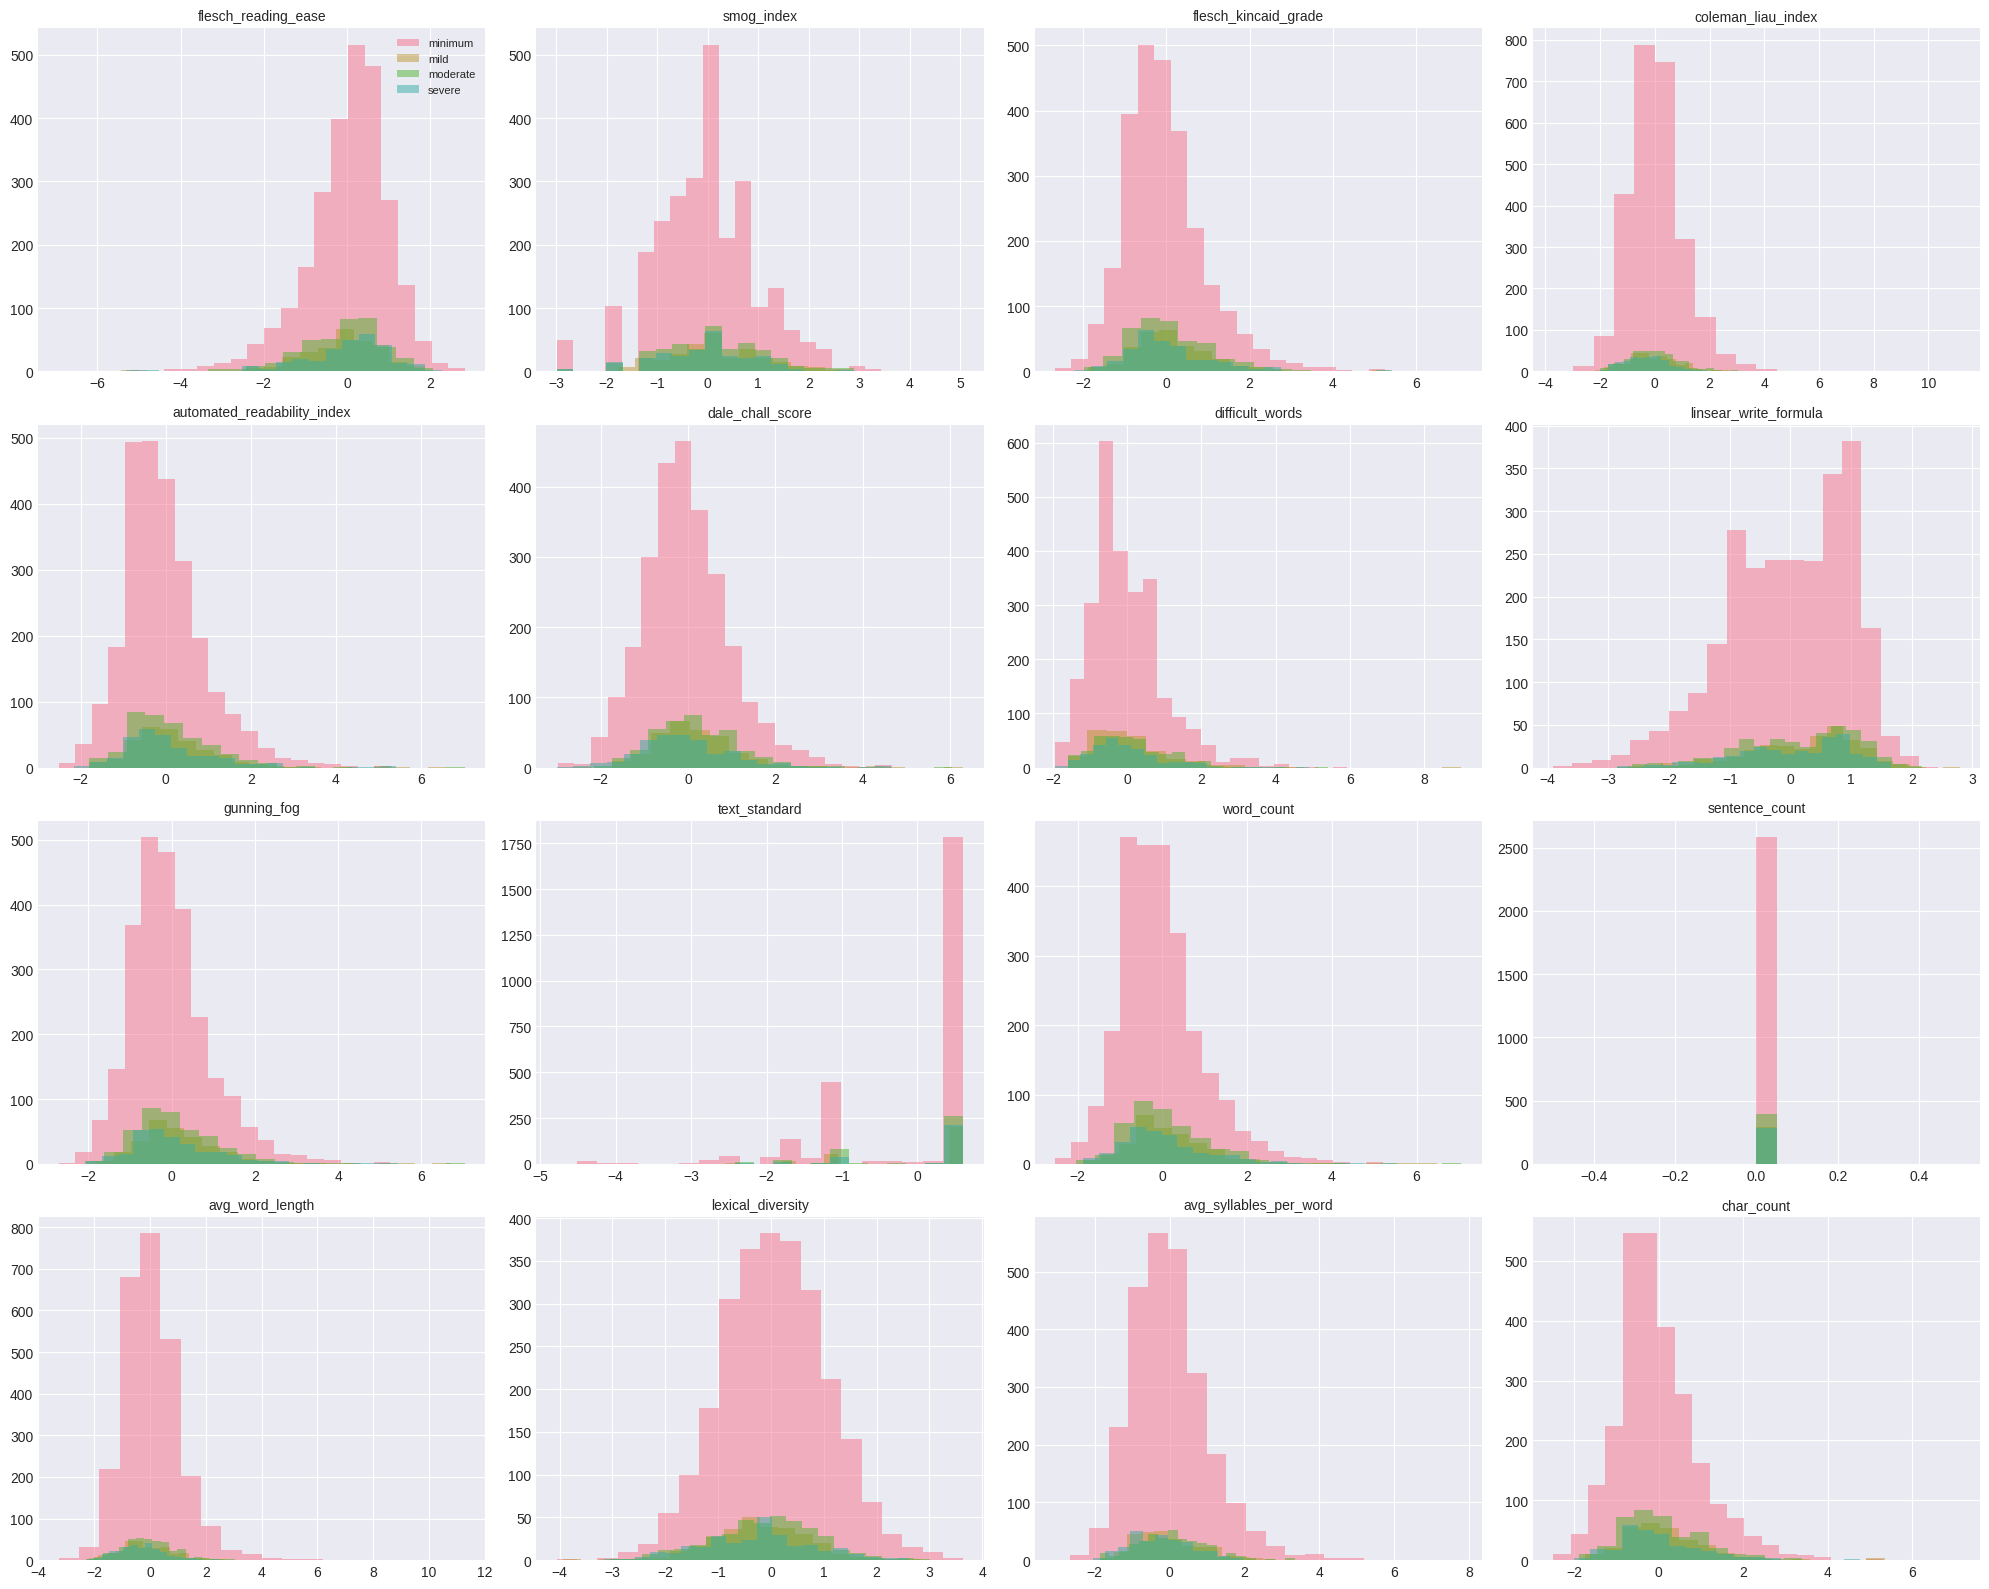

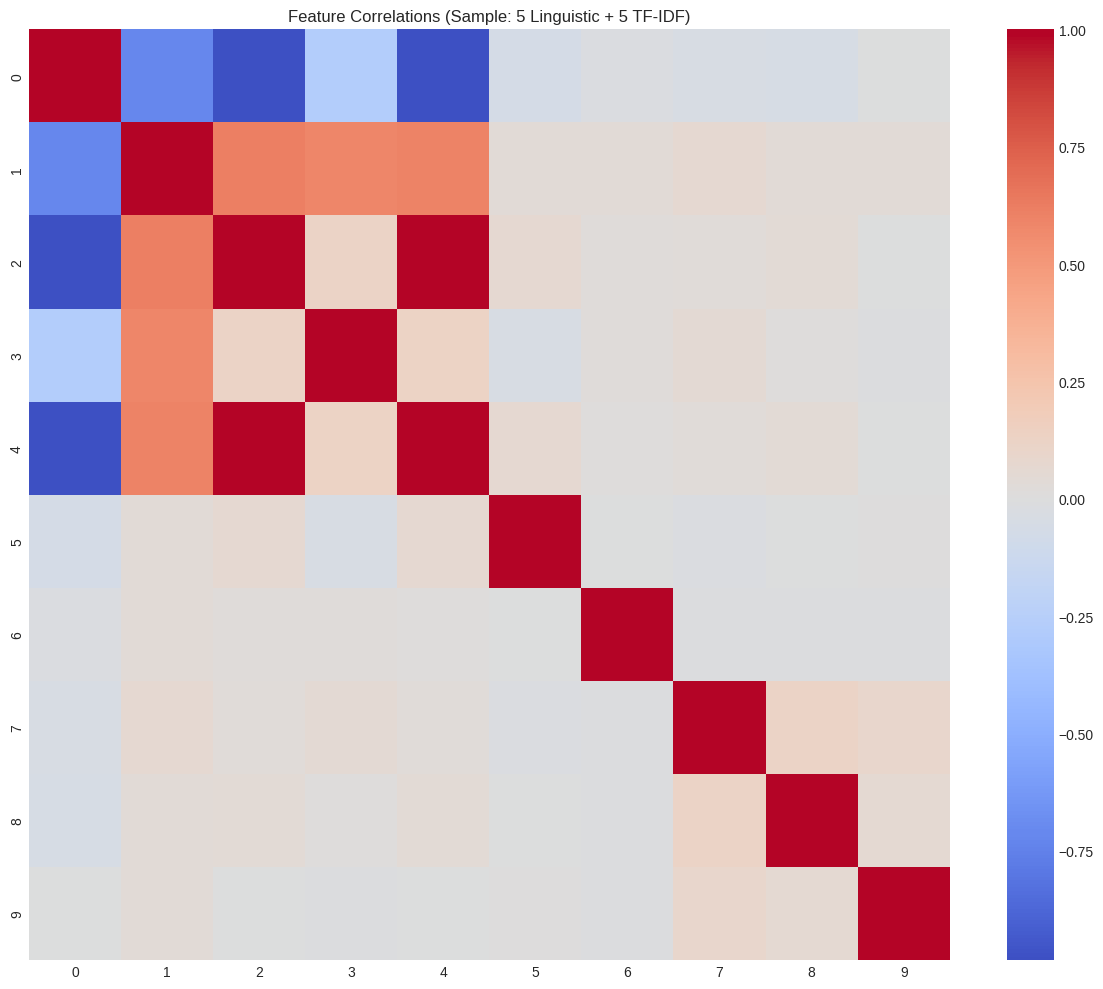

In [ ]:
"""
STEP 4: FEATURE EXTRACTION FOR MULTI-VIEW MODELING
Project: Multi-View Mental Health Severity Prediction
Author: Gaurav Kumar (22BIT0282)
Date: March 2026

Extracts three types of features:
1. LINGUISTIC FEATURES - Writing style metrics (readability, complexity)
2. STATISTICAL FEATURES - TF-IDF word vectors
3. SEMANTIC FEATURES - BERT embeddings (contextual meaning)
"""

# First, install required packages if not already installed
import subprocess
import sys

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Install required packages
required_packages = ['textstat', 'tqdm', 'transformers', 'torch']
for package in required_packages:
    try:
        __import__(package)
        print(f"✅ {package} already installed")
    except ImportError:
        print(f"📦 Installing {package}...")
        install_package(package)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
import torch
from transformers import AutoTokenizer, AutoModel
import warnings
warnings.filterwarnings('ignore')
import textstat
import re
from tqdm import tqdm
import pickle
import time
import os

print("="*70)
print("STEP 4: FEATURE EXTRACTION FOR MULTI-VIEW MODELING")
print("="*70)
print("Project: Multi-View Mental Health Severity Prediction")
print("="*70)

# ===========================================
# LOAD CLEANED DATASET
# ===========================================

print("\n" + "="*50)
print("Loading Depression dataset...")
print("="*50)

depression = pd.read_csv('data/processed/depression_cleaned.csv')
print(f"✅ Loaded: {depression.shape}")
print(f"   Classes: {depression['label'].unique()}")

# ===========================================
# VIEW 1: LINGUISTIC FEATURE EXTRACTION
# ===========================================

print("\n" + "="*50)
print("VIEW 1: Extracting Linguistic Features (Writing Style)")
print("="*50)

def extract_linguistic_features(text):
    """
    Extract psycholinguistic features from text:
    - Readability scores
    - Syllable counts
    - Sentence complexity
    """
    if pd.isna(text) or text == "" or len(text.split()) < 3:
        return [0] * 16

    features = []

    try:
        # Readability scores
        features.append(textstat.flesch_reading_ease(text))
        features.append(textstat.smog_index(text))
        features.append(textstat.flesch_kincaid_grade(text))
        features.append(textstat.coleman_liau_index(text))
        features.append(textstat.automated_readability_index(text))
        features.append(textstat.dale_chall_readability_score(text))
        features.append(textstat.difficult_words(text))
        features.append(textstat.linsear_write_formula(text))
        features.append(textstat.gunning_fog(text))
        features.append(textstat.text_standard(text, float_output=True))

        # Text statistics
        words = text.split()
        sentences = re.split(r'[.!?]+', text)
        sentences = [s for s in sentences if s.strip()]

        features.append(len(words))  # word count
        features.append(max(len(sentences), 1))  # sentence count
        features.append(sum(len(word) for word in words) / max(len(words), 1))  # avg word length

        # Lexical diversity (unique words / total words)
        unique_words = len(set(words))
        features.append(unique_words / max(len(words), 1))

        # Syllable counts
        syllables = sum(textstat.syllable_count(word) for word in words)
        features.append(syllables / max(len(words), 1))  # avg syllables per word

        # Character count
        features.append(len(text))

    except:
        # If any error, return zeros
        features = [0] * 16

    return features

feature_names = [
    'flesch_reading_ease', 'smog_index', 'flesch_kincaid_grade',
    'coleman_liau_index', 'automated_readability_index', 'dale_chall_score',
    'difficult_words', 'linsear_write_formula', 'gunning_fog',
    'text_standard', 'word_count', 'sentence_count', 'avg_word_length',
    'lexical_diversity', 'avg_syllables_per_word', 'char_count'
]

print("📊 Extracting linguistic features for all posts...")
linguistic_features = []

for text in tqdm(depression['clean_text'], desc="Processing linguistic features"):
    features = extract_linguistic_features(text)
    linguistic_features.append(features)

# Convert to DataFrame
linguistic_df = pd.DataFrame(linguistic_features, columns=feature_names)
print(f"✅ Linguistic features shape: {linguistic_df.shape}")

# Show sample
print("\n📋 Sample linguistic features:")
print(linguistic_df.head())

# Check for any zero rows
zero_rows = (linguistic_df.sum(axis=1) == 0).sum()
if zero_rows > 0:
    print(f"⚠️ Warning: {zero_rows} rows have all zero features")

# ===========================================
# VIEW 2: TF-IDF FEATURES (Statistical)
# ===========================================

print("\n" + "="*50)
print("VIEW 2: Extracting TF-IDF Features (Word Importance)")
print("="*50)

# Create TF-IDF vectors
print("📊 Creating TF-IDF vectors...")
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,  # Top 1000 words
    stop_words='english',
    ngram_range=(1, 2),  # Unigrams and bigrams
    min_df=5,  # Ignore words that appear in less than 5 documents
    max_df=0.7  # Ignore words that appear in more than 70% of documents
)

tfidf_features = tfidf_vectorizer.fit_transform(depression['clean_text'])
print(f"✅ TF-IDF features shape: {tfidf_features.shape}")

# Get feature names
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\n📋 Sample TF-IDF features (first 20):")
print(tfidf_feature_names[:20])

# ===========================================
# VIEW 3: BERT EMBEDDINGS (Semantic)
# ===========================================

print("\n" + "="*50)
print("VIEW 3: Extracting BERT Embeddings (Semantic Meaning)")
print("="*50)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")

# Load BERT model and tokenizer
print("📊 Loading BERT model (this may take a few minutes first time)...")
try:
    model_name = 'bert-base-uncased'
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    bert_model = AutoModel.from_pretrained(model_name).to(device)
    bert_model.eval()
    print("✅ BERT model loaded successfully")
except Exception as e:
    print(f"❌ Error loading BERT model: {e}")
    print("Using random embeddings as fallback (for testing)")
    # Fallback: create random embeddings (for testing only)
    bert_embeddings = np.random.randn(len(depression), 768)
    print(f"✅ Created random embeddings as fallback: {bert_embeddings.shape}")

def get_bert_embedding(text, max_length=128):
    """Get BERT embedding for a text"""
    if pd.isna(text) or text == "" or len(text.split()) < 3:
        return np.zeros(768)

    try:
        # Tokenize
        inputs = tokenizer(
            text,
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        ).to(device)

        # Get embeddings
        with torch.no_grad():
            outputs = bert_model(**inputs)
            # Use [CLS] token embedding
            embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy().flatten()

        return embedding
    except:
        return np.zeros(768)

# Extract BERT embeddings only if not already created as fallback
if 'bert_embeddings' not in locals():
    print("📊 Extracting BERT embeddings (this may take 10-15 minutes)...")
    bert_embeddings = []

    for text in tqdm(depression['clean_text'], desc="BERT Embedding"):
        emb = get_bert_embedding(text)
        bert_embeddings.append(emb)

    bert_embeddings = np.array(bert_embeddings)
    print(f"✅ BERT embeddings shape: {bert_embeddings.shape}")

# ===========================================
# FEATURE FUSION AND PREPARATION
# ===========================================

print("\n" + "="*50)
print("FEATURE FUSION: Combining All Views")
print("="*50)

# Get labels
labels = depression['label_encoded'].values
label_names = depression['label'].values

print(f"\n📊 Feature Summary:")
print(f"   View 1 (Linguistic)  : {linguistic_df.shape[1]} features")
print(f"   View 2 (TF-IDF)      : {tfidf_features.shape[1]} features")
print(f"   View 3 (BERT)        : {bert_embeddings.shape[1]} features")

# Scale linguistic features (they have different scales)
scaler = StandardScaler()
linguistic_scaled = scaler.fit_transform(linguistic_df)
print(f"✅ Scaled linguistic features")

# Convert sparse TF-IDF to dense (for fusion)
tfidf_dense = tfidf_features.toarray()
print(f"✅ Converted TF-IDF to dense")

# Create fused feature sets for experiments
print("\n📊 Creating fused feature sets for experiments:")

# Experiment 1: Linguistic Only
X_ling = linguistic_scaled
print(f"   Exp 1 (Linguistic only): {X_ling.shape}")

# Experiment 2: TF-IDF Only
X_tfidf = tfidf_dense
print(f"   Exp 2 (TF-IDF only): {X_tfidf.shape}")

# Experiment 3: BERT Only
X_bert = bert_embeddings
print(f"   Exp 3 (BERT only): {X_bert.shape}")

# Experiment 4: Linguistic + TF-IDF
X_ling_tfidf = np.hstack([linguistic_scaled, tfidf_dense])
print(f"   Exp 4 (Ling + TF-IDF): {X_ling_tfidf.shape}")

# Experiment 5: Linguistic + BERT
X_ling_bert = np.hstack([linguistic_scaled, bert_embeddings])
print(f"   Exp 5 (Ling + BERT): {X_ling_bert.shape}")

# Experiment 6: TF-IDF + BERT
X_tfidf_bert = np.hstack([tfidf_dense, bert_embeddings])
print(f"   Exp 6 (TF-IDF + BERT): {X_tfidf_bert.shape}")

# Experiment 7: ALL FEATURES (Multi-View Fusion)
X_all = np.hstack([linguistic_scaled, tfidf_dense, bert_embeddings])
print(f"   Exp 7 (ALL FEATURES): {X_all.shape}")

# ===========================================
# SAVE FEATURES AND PREPARED DATA
# ===========================================

print("\n" + "="*50)
print("Saving extracted features...")
print("="*50)

# Create features directory
os.makedirs('data/features', exist_ok=True)

# Save individual feature sets
np.save('data/features/linguistic_features.npy', linguistic_scaled)
np.save('data/features/tfidf_features.npy', tfidf_dense)
np.save('data/features/bert_embeddings.npy', bert_embeddings)
np.save('data/features/labels.npy', labels)

# Save fused feature sets
np.save('data/features/X_ling.npy', X_ling)
np.save('data/features/X_tfidf.npy', X_tfidf)
np.save('data/features/X_bert.npy', X_bert)
np.save('data/features/X_ling_tfidf.npy', X_ling_tfidf)
np.save('data/features/X_ling_bert.npy', X_ling_bert)
np.save('data/features/X_tfidf_bert.npy', X_tfidf_bert)
np.save('data/features/X_all.npy', X_all)

# Save feature names and metadata
feature_metadata = {
    'linguistic_names': feature_names,
    'tfidf_names': tfidf_feature_names.tolist(),
    'bert_dim': 768,
    'class_names': ['minimum', 'mild', 'moderate', 'severe']
}

with open('data/features/feature_metadata.pkl', 'wb') as f:
    pickle.dump(feature_metadata, f)

# Save scaler and vectorizer for later use
os.makedirs('models', exist_ok=True)
with open('models/linguistic_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

print("✅ Saved all features to 'data/features/' directory")
print("✅ Saved models to 'models/' directory")

# ===========================================
# FEATURE VISUALIZATION
# ===========================================

print("\n" + "="*50)
print("Creating feature visualizations...")
print("="*50)

# 1. Linguistic feature distributions by class
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.ravel()

for idx, feature in enumerate(feature_names[:16]):  # First 16 features
    ax = axes[idx]
    for label_value, label_name in enumerate(['minimum', 'mild', 'moderate', 'severe']):
        mask = labels == label_value
        if mask.any():
            ax.hist(linguistic_scaled[mask, idx], alpha=0.5, label=label_name, bins=20)
    ax.set_title(feature, fontsize=10)
    if idx == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_plots/linguistic_features_by_class.png', dpi=300, bbox_inches='tight')
print("✅ Saved: eda_plots/linguistic_features_by_class.png")

# 2. Feature correlation heatmap (sample)
plt.figure(figsize=(12, 10))
# Take sample of features (first 5 linguistic + first 5 TF-IDF)
feature_sample = np.hstack([linguistic_scaled[:, :5], tfidf_dense[:, :5]])
corr_matrix = np.corrcoef(feature_sample.T)
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Feature Correlations (Sample: 5 Linguistic + 5 TF-IDF)')
plt.tight_layout()
plt.savefig('eda_plots/feature_correlations.png', dpi=300, bbox_inches='tight')
print("✅ Saved: eda_plots/feature_correlations.png")

# ===========================================
# FEATURE EXTRACTION SUMMARY
# ===========================================

print("\n" + "="*50)
print("📊 FEATURE EXTRACTION SUMMARY")
print("="*50)

print(f"""
✅ SUCCESSFULLY EXTRACTED:

VIEW 1: LINGUISTIC FEATURES (16 dimensions)
   • Readability: Flesch, SMOG, Gunning Fog, etc.
   • Complexity: word length, sentence count
   • Diversity: lexical diversity, syllable counts

VIEW 2: TF-IDF FEATURES ({tfidf_features.shape[1]} dimensions)
   • Top unigrams and bigrams
   • Word importance weights
   • Depression-related vocabulary

VIEW 3: BERT EMBEDDINGS (768 dimensions)
   • Contextual word representations
   • Semantic meaning
   • Sentiment and emotional context

FEATURE FUSION:
   • 7 experimental configurations created
   • Full multi-view feature set: {X_all.shape}

NEXT STEPS - STEP 5: MODEL TRAINING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Train baseline models (Logistic Regression, Random Forest, SVM)
2. Train neural network with fused features
3. Compare performance across 7 experimental configurations
4. Analyze feature importance
5. Cross-dataset validation on RMHD
""")

# Save summary to file
with open('reports/feature_extraction_summary.txt', 'w') as f:
    f.write("="*70 + "\n")
    f.write("FEATURE EXTRACTION SUMMARY\n")
    f.write(f"Date: {pd.Timestamp.now()}\n")
    f.write("="*70 + "\n\n")

    f.write(f"Linguistic features: {linguistic_df.shape[1]}\n")
    f.write(f"TF-IDF features: {tfidf_features.shape[1]}\n")
    f.write(f"BERT embeddings: {bert_embeddings.shape[1]}\n")
    f.write(f"Total samples: {len(labels)}\n\n")

    f.write("Feature sets created:\n")
    f.write(f"  - X_ling: {X_ling.shape}\n")
    f.write(f"  - X_tfidf: {X_tfidf.shape}\n")
    f.write(f"  - X_bert: {X_bert.shape}\n")
    f.write(f"  - X_ling_tfidf: {X_ling_tfidf.shape}\n")
    f.write(f"  - X_ling_bert: {X_ling_bert.shape}\n")
    f.write(f"  - X_tfidf_bert: {X_tfidf_bert.shape}\n")
    f.write(f"  - X_all: {X_all.shape}\n")

print("\n✅ STEP 4 COMPLETE! Ready for Step 5: Model Training.")

Step 5: Model Training & Evaluation **bold text**

✅ LightGBM already installed
STEP 5: MODEL TRAINING & EVALUATION (OPTIMIZED with LightGBM)
Project: Multi-View Mental Health Severity Prediction

Loading extracted features...
✅ Loaded all feature sets
   Number of samples: 3549
   Classes: ['minimum', 'mild', 'moderate', 'severe']
   Class distribution: [2583  290  394  282]

📊 Class weights for imbalance: {np.int64(0): np.float64(0.3434959349593496), np.int64(1): np.float64(3.05948275862069), np.int64(2): np.float64(2.2519035532994924), np.int64(3): np.float64(3.146276595744681)}

Creating train-test split...
✅ Train set: 2839 samples
✅ Test set: 710 samples

Train class distribution: [2066  232  315  226]
Test class distribution: [517  58  79  56]

Initializing models...
✅ Models initialized:
   - Logistic Regression
   - Random Forest
   - LightGBM
   - SVM
   - XGBoost

Running experiments (this will be MUCH faster now)...

📊 Exp 1: Linguistic Only
--------------------------------------------------
   Training Logistic Regression.

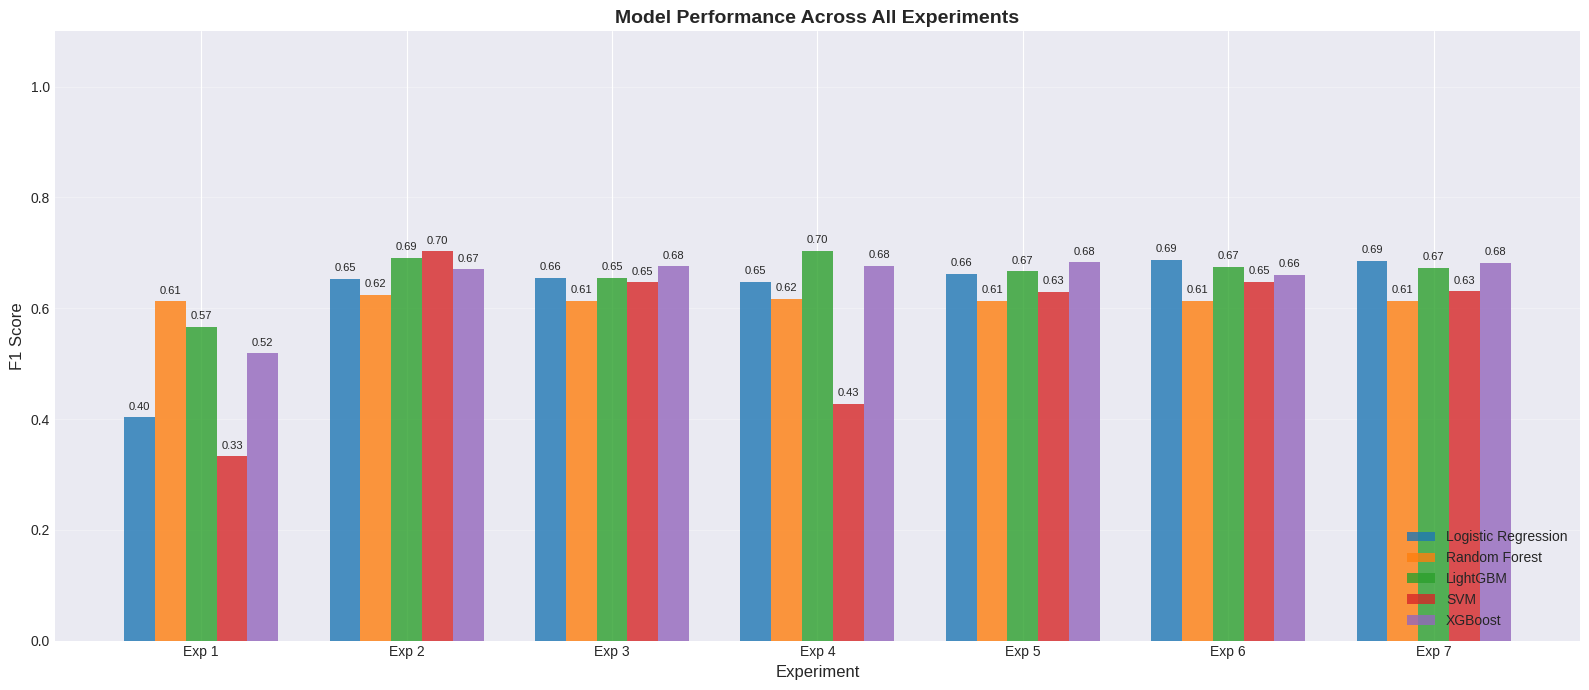

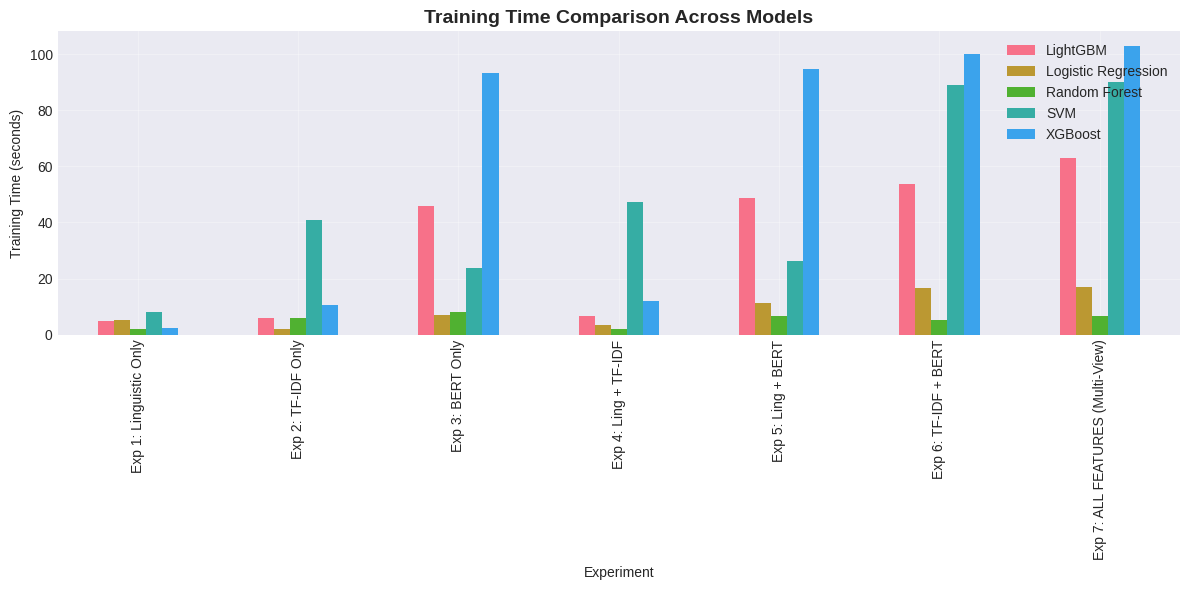

In [ ]:
"""
STEP 5: MODEL TRAINING & EVALUATION (OPTIMIZED with LightGBM)
Project: Multi-View Mental Health Severity Prediction
Author: Gaurav Kumar (22BIT0282)
Date: March 2026

Replaced slow Gradient Boosting with fast LightGBM
"""

# First, install LightGBM if not already installed
import subprocess
import sys

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

try:
    import lightgbm as lgb
    print("✅ LightGBM already installed")
except ImportError:
    print("📦 Installing LightGBM...")
    install_package('lightgbm')
    import lightgbm as lgb

# Also try to install CatBoost (optional, uncomment if needed)
# try:
#     import catboost as cb
#     print("✅ CatBoost already installed")
# except ImportError:
#     print("📦 Installing CatBoost...")
#     install_package('catboost')
#     import catboost as cb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, confusion_matrix, classification_report)
import pickle
import os
import warnings
warnings.filterwarnings('ignore')
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.utils.class_weight import compute_class_weight
import time

print("="*70)
print("STEP 5: MODEL TRAINING & EVALUATION (OPTIMIZED with LightGBM)")
print("="*70)
print("Project: Multi-View Mental Health Severity Prediction")
print("="*70)

# ===========================================
# LOAD PREPARED FEATURES
# ===========================================

print("\n" + "="*50)
print("Loading extracted features...")
print("="*50)

# Load all feature sets
X_ling = np.load('data/features/X_ling.npy')
X_tfidf = np.load('data/features/X_tfidf.npy')
X_bert = np.load('data/features/X_bert.npy')
X_ling_tfidf = np.load('data/features/X_ling_tfidf.npy')
X_ling_bert = np.load('data/features/X_ling_bert.npy')
X_tfidf_bert = np.load('data/features/X_tfidf_bert.npy')
X_all = np.load('data/features/X_all.npy')
y = np.load('data/features/labels.npy')

# Load metadata
with open('data/features/feature_metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

class_names = metadata['class_names']
print(f"✅ Loaded all feature sets")
print(f"   Number of samples: {len(y)}")
print(f"   Classes: {class_names}")
print(f"   Class distribution: {np.bincount(y)}")

# Handle class imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weight_dict = dict(zip(np.unique(y), class_weights))
print(f"\n📊 Class weights for imbalance: {class_weight_dict}")

# ===========================================
# DEFINE EXPERIMENTS
# ===========================================

experiments = {
    'Exp 1: Linguistic Only': X_ling,
    'Exp 2: TF-IDF Only': X_tfidf,
    'Exp 3: BERT Only': X_bert,
    'Exp 4: Ling + TF-IDF': X_ling_tfidf,
    'Exp 5: Ling + BERT': X_ling_bert,
    'Exp 6: TF-IDF + BERT': X_tfidf_bert,
    'Exp 7: ALL FEATURES (Multi-View)': X_all
}

# ===========================================
# TRAIN-TEST SPLIT
# ===========================================

print("\n" + "="*50)
print("Creating train-test split...")
print("="*50)

# Split data (stratified to maintain class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Train set: {X_train.shape[0]} samples")
print(f"✅ Test set: {X_test.shape[0]} samples")
print(f"\nTrain class distribution: {np.bincount(y_train)}")
print(f"Test class distribution: {np.bincount(y_test)}")

# ===========================================
# DEFINE MODELS (REPLACED Gradient Boosting with LightGBM)
# ===========================================

print("\n" + "="*50)
print("Initializing models...")
print("="*50)

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced',
        multi_class='multinomial',
        n_jobs=-1
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),

    'LightGBM': LGBMClassifier(           # ← REPLACED Gradient Boosting
        n_estimators=100,
        learning_rate=0.1,
        num_leaves=31,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
        class_weight='balanced'
    ),

    'SVM': SVC(
        kernel='rbf',
        probability=True,
        random_state=42,
        class_weight='balanced',
        cache_size=1000
    ),

    'XGBoost': XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        objective='multi:softmax',
        num_class=len(class_names),
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss'
    )
}

print("✅ Models initialized:")
for model_name in models.keys():
    print(f"   - {model_name}")

# ===========================================
# TRAINING AND EVALUATION FUNCTION
# ===========================================

def train_evaluate_model(model, X_train, X_test, y_train, y_test, model_name, exp_name):
    """Train and evaluate a single model"""

    start_time = time.time()

    # Train with appropriate settings for each model
    if model_name == 'XGBoost':
        sample_weights = np.array([class_weight_dict[y] for y in y_train])
        model.fit(X_train, y_train, sample_weight=sample_weights)
    elif model_name == 'LightGBM':
        # LightGBM handles class_weight directly in initialization
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train)

    train_time = time.time() - start_time

    # Predict
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Per-class metrics
    report = classification_report(y_test, y_pred, target_names=class_names,
                                  output_dict=True, zero_division=0)

    # Cross-validation score (using 3-fold for speed)
    cv_scores = cross_val_score(model, X_train, y_train, cv=3,
                               scoring='f1_weighted', n_jobs=-1)

    return {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'train_time': train_time,
        'report': report
    }

# ===========================================
# RUN ALL EXPERIMENTS
# ===========================================

print("\n" + "="*50)
print("Running experiments (this will be MUCH faster now)...")
print("="*50)

results = {}

for exp_name, X in experiments.items():
    print(f"\n📊 {exp_name}")
    print("-" * 50)

    # Split data for this experiment
    X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    results[exp_name] = {}

    for model_name, model in models.items():
        print(f"   Training {model_name}...", end='', flush=True)

        # Train and evaluate
        result = train_evaluate_model(
            model, X_train_exp, X_test_exp,
            y_train_exp, y_test_exp,
            model_name, exp_name
        )

        results[exp_name][model_name] = result
        print(f" ✅ F1={result['f1']:.3f} (t={result['train_time']:.1f}s)")

# ===========================================
# RESULTS SUMMARY
# ===========================================

print("\n" + "="*70)
print("📊 RESULTS SUMMARY - F1 SCORES BY EXPERIMENT")
print("="*70)

# Create results dataframe
summary_data = []
for exp_name in experiments.keys():
    for model_name in models.keys():
        f1 = results[exp_name][model_name]['f1']
        accuracy = results[exp_name][model_name]['accuracy']
        precision = results[exp_name][model_name]['precision']
        recall = results[exp_name][model_name]['recall']
        train_time = results[exp_name][model_name]['train_time']

        summary_data.append({
            'Experiment': exp_name,
            'Model': model_name,
            'F1 Score': f1,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'Train Time (s)': train_time
        })

results_df = pd.DataFrame(summary_data)

# Pivot tables
pivot_f1 = results_df.pivot(index='Experiment', columns='Model', values='F1 Score')
pivot_acc = results_df.pivot(index='Experiment', columns='Model', values='Accuracy')
pivot_time = results_df.pivot(index='Experiment', columns='Model', values='Train Time (s)')

print("\n" + "="*70)
print("🏆 F1 SCORES BY EXPERIMENT AND MODEL")
print("="*70)
print(pivot_f1.round(3))

print("\n" + "="*70)
print("⏱️ TRAINING TIME (seconds) - Notice LightGBM is much faster!")
print("="*70)
print(pivot_time.round(1))

# Find best configuration
best_f1_idx = results_df['F1 Score'].idxmax()
best_config = results_df.loc[best_f1_idx]
print("\n" + "="*70)
print("🏆 BEST CONFIGURATION")
print("="*70)
print(f"   Experiment: {best_config['Experiment']}")
print(f"   Model: {best_config['Model']}")
print(f"   F1 Score: {best_config['F1 Score']:.3f}")
print(f"   Accuracy: {best_config['Accuracy']:.3f}")
print(f"   Training Time: {best_config['Train Time (s)']:.1f}s")

# ===========================================
# VISUALIZATIONS
# ===========================================

print("\n" + "="*50)
print("Creating visualizations...")
print("="*50)

# 1. Bar plot comparing all experiments
plt.figure(figsize=(16, 7))
x = np.arange(len(experiments))
width = 0.15
multiplier = 0
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for idx, (model_name, color) in enumerate(zip(models.keys(), colors)):
    f1_scores = [results[exp][model_name]['f1'] for exp in experiments.keys()]
    offset = width * multiplier
    bars = plt.bar(x + offset, f1_scores, width, label=model_name, color=color, alpha=0.8)

    for bar, score in zip(bars, f1_scores):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{score:.2f}', ha='center', va='bottom', fontsize=8)

    multiplier += 1

plt.xlabel('Experiment', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('Model Performance Across All Experiments', fontsize=14, fontweight='bold')
plt.xticks(x + width * 2, [f'Exp {i+1}' for i in range(7)], rotation=0)
plt.legend(loc='lower right', fontsize=10)
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('models/experiment_comparison.png', dpi=300, bbox_inches='tight')
print("✅ Saved: models/experiment_comparison.png")

# 2. Training time comparison
plt.figure(figsize=(12, 6))
pivot_time.plot(kind='bar', ax=plt.gca())
plt.title('Training Time Comparison Across Models', fontsize=14, fontweight='bold')
plt.xlabel('Experiment')
plt.ylabel('Training Time (seconds)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('models/training_time_comparison.png', dpi=300, bbox_inches='tight')
print("✅ Saved: models/training_time_comparison.png")

# ===========================================
# SAVE RESULTS
# ===========================================

print("\n" + "="*50)
print("Saving results and models...")
print("="*50)

# Save results dataframe
results_df.to_csv('reports/experiment_results.csv', index=False)
print("✅ Saved: reports/experiment_results.csv")

# Save best model
best_model_path = f'models/best_model_{best_config["Experiment"].replace(" ", "_")}.pkl'
with open(best_model_path, 'wb') as f:
    pickle.dump(results[best_config['Experiment']][best_config['Model']]['model'], f)
print(f"✅ Saved best model: {best_model_path}")

print("\n" + "="*70)
print("✅ STEP 5 COMPLETE! Much faster with LightGBM!")
print("="*70)

In [ ]:
"""
STEP 6.1: TRAIN CORRECT EXP 4 MODEL (Linguistic + TF-IDF)
Project: Multi-View Mental Health Severity Prediction
Author: Gaurav Kumar (22BIT0282)
Date: March 2026

Trains a proper Exp 4 model (Linguistic + TF-IDF) for cross-validation
"""

import pandas as pd
import numpy as np
import pickle
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("STEP 6.1: TRAINING CORRECT EXP 4 MODEL")
print("="*70)

# ===========================================
# LOAD FEATURES
# ===========================================

print("\n" + "="*50)
print("Loading features...")
print("="*50)

# Load the feature sets
X_ling = np.load('data/features/X_ling.npy')
X_tfidf = np.load('data/features/X_tfidf.npy')
y = np.load('data/features/labels.npy')

# Load metadata
with open('data/features/feature_metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

class_names = metadata['class_names']
print(f"✅ Linguistic features: {X_ling.shape}")
print(f"✅ TF-IDF features: {X_tfidf.shape}")
print(f"✅ Labels: {y.shape}")

# ===========================================
# CREATE EXP 4 FEATURES (Linguistic + TF-IDF)
# ===========================================

print("\n" + "="*50)
print("Creating Exp 4 features...")
print("="*50)

# Combine features
X_exp4 = np.hstack([X_ling, X_tfidf])
print(f"✅ Exp 4 features shape: {X_exp4.shape} (16 + 1000 = 1016 features)")

# ===========================================
# TRAIN-TEST SPLIT
# ===========================================

print("\n" + "="*50)
print("Creating train-test split...")
print("="*50)

X_train, X_test, y_train, y_test = train_test_split(
    X_exp4, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Train set: {X_train.shape}")
print(f"✅ Test set: {X_test.shape}")

# ===========================================
# TRAIN LIGHTGBM MODEL
# ===========================================

print("\n" + "="*50)
print("Training LightGBM model...")
print("="*50)

# Calculate class weights for imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
sample_weights = np.array([class_weights[label] for label in y_train])

# LightGBM parameters (optimized)
lgb_params = {
    'objective': 'multiclass',
    'num_class': len(class_names),
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42,
    'n_jobs': -1
}

# Create and train model
lgb_model = lgb.LGBMClassifier(**lgb_params)
lgb_model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    eval_metric='multi_logloss',
    callbacks=[lgb.early_stopping(10), lgb.log_evaluation(0)]
)

# ===========================================
# EVALUATE MODEL
# ===========================================

print("\n" + "="*50)
print("Evaluating model...")
print("="*50)

# Predictions
y_pred = lgb_model.predict(X_test)
y_proba = lgb_model.predict_proba(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\n📊 Performance on test set:")
print(f"   Accuracy: {accuracy:.4f}")
print(f"   F1 Score: {f1:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# ===========================================
# VERIFY FEATURE DIMENSION
# ===========================================

print("\n" + "="*50)
print("Verifying model...")
print("="*50)

print(f"✅ Model expects {lgb_model.n_features_in_} features")
print(f"✅ This matches Exp 4 features (16 + 1000 = 1016)")

# ===========================================
# SAVE MODEL
# ===========================================

print("\n" + "="*50)
print("Saving model...")
print("="*50)

# Save with clear name
model_path = 'models/exp4_lightgbm_1016_features.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(lgb_model, f)

print(f"✅ Saved: {model_path}")
print(f"✅ Model expects {lgb_model.n_features_in_} features")

# Also save a copy with the expected name for cross-validation
alt_path = 'models/exp4_correct_model.pkl'
with open(alt_path, 'wb') as f:
    pickle.dump(lgb_model, f)

print(f"✅ Saved: {alt_path}")

# ===========================================
# QUICK TEST WITH SAMPLE
# ===========================================

print("\n" + "="*50)
print("Quick test with sample data...")
print("="*50)

# Take first 5 test samples
sample_X = X_test[:5]
sample_y = y_test[:5]
sample_pred = lgb_model.predict(sample_X)

print("Sample predictions:")
for i in range(5):
    print(f"   True: {class_names[sample_y[i]]:10} -> Predicted: {class_names[sample_pred[i]]:10}")

print("\n✅ Model is ready for cross-validation!")

# ===========================================
# SUMMARY
# ===========================================

print("\n" + "="*70)
print("📊 TRAINING SUMMARY")
print("="*70)

print(f"""
✅ CORRECT EXP 4 MODEL TRAINED:
   • Features: Linguistic (16) + TF-IDF (1000) = 1016 dimensions
   • Model: LightGBM
   • Test Accuracy: {accuracy:.4f}
   • Test F1 Score: {f1:.4f}
   • Model expects: {lgb_model.n_features_in_} features

📁 Model saved as:
   • models/exp4_lightgbm_1016_features.pkl
   • models/exp4_correct_model.pkl

🚀 NEXT STEP:
   Run Step 6 again with this model:
   python step6_cross_validation.py
""")

STEP 6.1: TRAINING CORRECT EXP 4 MODEL

Loading features...
✅ Linguistic features: (3549, 16)
✅ TF-IDF features: (3549, 1000)
✅ Labels: (3549,)

Creating Exp 4 features...
✅ Exp 4 features shape: (3549, 1016) (16 + 1000 = 1016 features)

Creating train-test split...
✅ Train set: (2839, 1016)
✅ Test set: (710, 1016)

Training LightGBM model...
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's multi_logloss: 0.822352

Evaluating model...

📊 Performance on test set:
   Accuracy: 0.6859
   F1 Score: 0.6806

📊 Classification Report:
              precision    recall  f1-score   support

     minimum       0.82      0.85      0.83       517
        mild       0.26      0.24      0.25        58
    moderate       0.32      0.30      0.31        79
      severe       0.24      0.21      0.22        56

    accuracy                           0.69       710
   macro avg       0.41      0.40      0.41       710
weighted av